In [1]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunMod_1k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)

## Creating integration steps for z, s and t
(all arrays go backwards in time)

In [2]:
def z_at_age(age):
    
    # Function to calculate redshift for a given age of the universe
    def age_diff(z):
        return cosmo.age(z).to(apu.year).value - age
    
    # Use root_scalar to find the redshift that gives the specified age
    sol = root_scalar(
        age_diff, bracket=[0, 10], method='brentq', xtol=1e-12, rtol=1e-12)
    return sol.root


def get_redshift_array(days):

    # Today's date
    today = Time.now()
    
    # Calculate redshift for each day
    redshifts = jnp.zeros(days)
    age_today = cosmo.age(0).to(apu.year).value  # Age of the universe today
    for day in range(days):

        # Calculate the date for each day of the past year
        past_date = today - day*apu.day
        
        # Calculate the lookback time in years
        lookback_time = (today - past_date).to(apu.year).value
        
        # Calculate the age of the universe at this lookback time
        age_of_universe_then = age_today - lookback_time
        
        # Find the redshift corresponding to this age of the universe
        redshift = z_at_age(age_of_universe_then)
        
        # Store the redshift value in the array
        redshifts = redshifts.at[day].set(redshift)
    
    return redshifts


def s_of_z(z, args):
    """
    Convert redshift to time variable s with eqn. 4.1 in Mertsch et al.
    (2020), keeping only Omega_M and Omega_L in the Hubble eqn. for H(z).

    Args:
        z (float): redshift

    Returns:
        float: time variable s (in [seconds] if 1/H0 factor is included)
    """    

    def s_integrand(z):        

        # We need value of H0 in units of 1/s.
        H0_val = args.H0/(1/args.s)
        a_dot = np.sqrt(args.Omega_M*(1.+z)**3 + args.Omega_L)/(1.+z)*H0_val
        s_int = 1./a_dot

        return s_int

    s_of_z, _ = quad(s_integrand, 0., z)

    return jnp.float64(s_of_z)


# Function to generate t_int_steps using Astropy
def generate_t_int_steps(z_int_steps):
    # Convert z_int_steps to a numpy array if it's not already
    z_int_steps_np = np.array(z_int_steps)
    
    # Calculate lookback times using Astropy
    t_int_steps_astropy = cosmo.lookback_time(z_int_steps_np)
    
    # Convert to seconds and then to a JAX array
    t_int_steps = jnp.array(t_int_steps_astropy.to(apu.s).value)
    
    return t_int_steps


# 2 years plus additional day, s.t. integration routine can pick 2nd last
# (see notes in backtrack_1_neutrino function)
days = (365*2)+1

# Get the redshift array for these (past) days
z_int_steps_2years = get_redshift_array(days)

# Convert to integration variable s
s_int_steps_2years = jnp.array(
    [s_of_z(z, Params()) for z in z_int_steps_2years])

# Convert to "physical" time in seconds
t_int_steps_2years = generate_t_int_steps(z_int_steps_2years)

jnp.save(f"{sim_folder}/z_int_steps_2years.npy", z_int_steps_2years)
jnp.save(f"{sim_folder}/s_int_steps_2years.npy", s_int_steps_2years)
jnp.save(f"{sim_folder}/t_int_steps_2years.npy", t_int_steps_2years)

## Methodology for Earth's orbit
(all arrays go forward in time)

### Functions and validations

In [3]:
def calculate_fractional_day_numbers(year):
    """
    Calculate the fractional day number n for each day of the given year.
    
    :param year: The year for which to calculate the fractional day numbers
    :return: A list of tuples, each containing (date, fractional day number)
    """
    results = []
    start_date = datetime(year, 1, 1)
    
    for day in range(
        366 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 365):
        current_date = start_date + timedelta(days=day)
        Y, M, D = current_date.year, current_date.month, current_date.day
        
        Y_tilde = Y - 1 if M <= 2 else Y
        M_tilde = M + 12 if M <= 2 else M
        
        n = np.floor(365.25 * Y_tilde) + np.floor(30.61 * (M_tilde + 1)) + D - 730563.5
        
        results.append((current_date.strftime('%Y-%m-%d'), n))
    
    return results


def calculate_average_ecliptic_vectors(year):
    """
    Calculate the average ecliptic unit vectors ϵ_x and ϵ_y for the given year.
    
    :param year: The year for which to calculate the average ecliptic vectors
    :return: A tuple containing (year, average ϵ_x, average ϵ_y)
    """
    # Constants for ϵ_x and ϵ_y calculations
    eps_x_0 = np.array([0.054876, -0.494109, 0.867666])
    eps_x_T = np.array([-0.024232, -0.002689, 1.546e-6])
    eps_y_0 = np.array([0.993821, 0.110992, 0.000352])
    eps_y_T = np.array([0.001316, -0.011851, 0.021267])
    
    eps_x_sum = np.zeros(3)
    eps_y_sum = np.zeros(3)
    
    # Get fractional day numbers for the year
    fractional_days = calculate_fractional_day_numbers(year)
    
    for _, n in fractional_days:
        # Calculate T
        T = n / 36525
        
        # Calculate ϵ_x and ϵ_y for this day
        eps_x = eps_x_0 + eps_x_T * T
        eps_y = eps_y_0 + eps_y_T * T
        
        # Add to the sum
        eps_x_sum += eps_x
        eps_y_sum += eps_y
    
    # Calculate averages
    days_in_year = len(fractional_days)
    eps_x_avg = eps_x_sum / days_in_year
    eps_y_avg = eps_y_sum / days_in_year
    
    # Normalize the average vectors
    eps_x_avg /= np.linalg.norm(eps_x_avg)
    eps_y_avg /= np.linalg.norm(eps_y_avg)
    
    return eps_x_avg, eps_y_avg


def calculate_earth_position(year):
    """
    Calculate Earth's position relative to the Sun in ecliptic coordinates for each day of the year.
    
    :param year: The year for which to calculate Earth's position
    :return: A list of tuples, each containing (date, position vector)
    """
    # Constants
    e = 0.9574  # eccentricity in degrees
    e_rad = np.radians(e)

    # Get fractional day numbers and ecliptic vectors for the year
    fractional_days = calculate_fractional_day_numbers(year)
    eps_x, eps_y = calculate_average_ecliptic_vectors(year)

    results = []

    for date, n in fractional_days:
        # Calculate L, g, and varpi
        L = np.radians(280.460 + 0.9856474 * n)
        g = np.radians(357.528 + 0.9856003 * n)
        varpi = np.radians(282.932 + 0.0000471 * n)

        # Calculate ecliptic longitude
        l = L + 2 * e_rad * np.sin(g) + 5/4 * e_rad**2 * np.sin(2*g)

        # Calculate Earth-Sun distance (in AU)
        r = 1.00014 - 0.01671 * np.cos(g) - 0.00014 * np.cos(2*g)

        # Calculate position vector
        position = r * (np.cos(l) * eps_x + np.sin(l) * eps_y)

        results.append((date, position))

    return results


def calculate_earth_velocity(year):
    """
    Calculate Earth's velocity for each day of the year.
    
    :param year: The year for which to calculate Earth's velocity
    :return: A list of tuples, each containing (date, velocity vector)
    """
    # Constants
    e = 0.9574  # eccentricity in degrees
    e_rad = np.radians(e)
    u_E_avg = 29.79  # Average Earth velocity in km/s

    # Get fractional day numbers and ecliptic vectors for the year
    fractional_days = calculate_fractional_day_numbers(year)
    eps_x, eps_y = calculate_average_ecliptic_vectors(year)

    results = []

    for date, n in fractional_days:
        # Calculate L and varpi
        L = np.radians(280.460 + 0.9856474 * n)
        varpi = np.radians(282.932 + 0.0000471 * n)

        # Calculate velocity components
        v_x = -u_E_avg * (np.sin(L) + e_rad * np.sin(2*L - varpi))
        v_y = u_E_avg * (np.cos(L) + e_rad * np.cos(2*L - varpi))

        # Calculate velocity vector
        velocity = v_x * eps_x + v_y * eps_y

        results.append((date, velocity))

    return results


### =========== ###
### Computing n ###
### =========== ###

year = 2023
fractional_days = calculate_fractional_day_numbers(year)
print(f"{len(fractional_days)} days for year {year}")

# Verify the example given (31st January 2009)
verification_date = datetime(2009, 1, 31)
Y, M, D = verification_date.year, verification_date.month, verification_date.day
Y_tilde = Y - 1 if M <= 2 else Y
M_tilde = M + 12 if M <= 2 else M
n_verification = np.floor(365.25 * Y_tilde) + np.floor(30.61 * (M_tilde + 1)) + D - 730563.5
print(f"\nVerification for 31st January 2009:")
print(f"Calculated n: {n_verification}")
print(f"Expected n: 3318.25 (at 6 p.m. GMT, our result is for 0:00 AM GMT)")


### ================ ###
### Ecliptic vectors ###
### ================ ###

eps_vectors = calculate_average_ecliptic_vectors(year)

print(f"Average ecliptic unit vectors for {year}:")
print(f"  ϵ_x = {eps_vectors[0]}")
print(f"  ϵ_y = {eps_vectors[1]}")

# Verify that the vectors are unit vectors
eps_x_magnitude = np.linalg.norm(eps_vectors[0])
eps_y_magnitude = np.linalg.norm(eps_vectors[1])
print(f"\nVerification:")
print(f"Magnitude of average ϵ_x: {eps_x_magnitude:.10f}")
print(f"Magnitude of average ϵ_y: {eps_y_magnitude:.10f}")

# Check orthogonality
dot_product = np.dot(eps_vectors[0], eps_vectors[1])
print(f"Dot product of ϵ_x and ϵ_y: {dot_product:.10f}")


### =============== ###
### Earth positions ###
### =============== ###

earth_positions = calculate_earth_position(year)

# Verify the magnitude of the position vector (should be close to 1 AU)
first_day = earth_positions[0]
position_magnitude = np.linalg.norm(first_day[1])
print(f"\nVerification for {first_day[0]}:")
print(f"Magnitude of position vector: {position_magnitude:.10f} AU")

365 days for year 2023

Verification for 31st January 2009:
Calculated n: 3317.5
Expected n: 3318.25 (at 6 p.m. GMT, our result is for 0:00 AM GMT)
Average ecliptic unit vectors for 2023:
  ϵ_x = [ 0.04918127 -0.49473286  0.86765235]
  ϵ_y = [0.99411415 0.10820555 0.00534915]

Verification:
Magnitude of average ϵ_x: 1.0000000000
Magnitude of average ϵ_y: 1.0000000000
Dot product of ϵ_x and ϵ_y: 0.0000001537

Verification for 2023-01-01:
Magnitude of position vector: 0.9833126525 AU


### Plots and comparisons

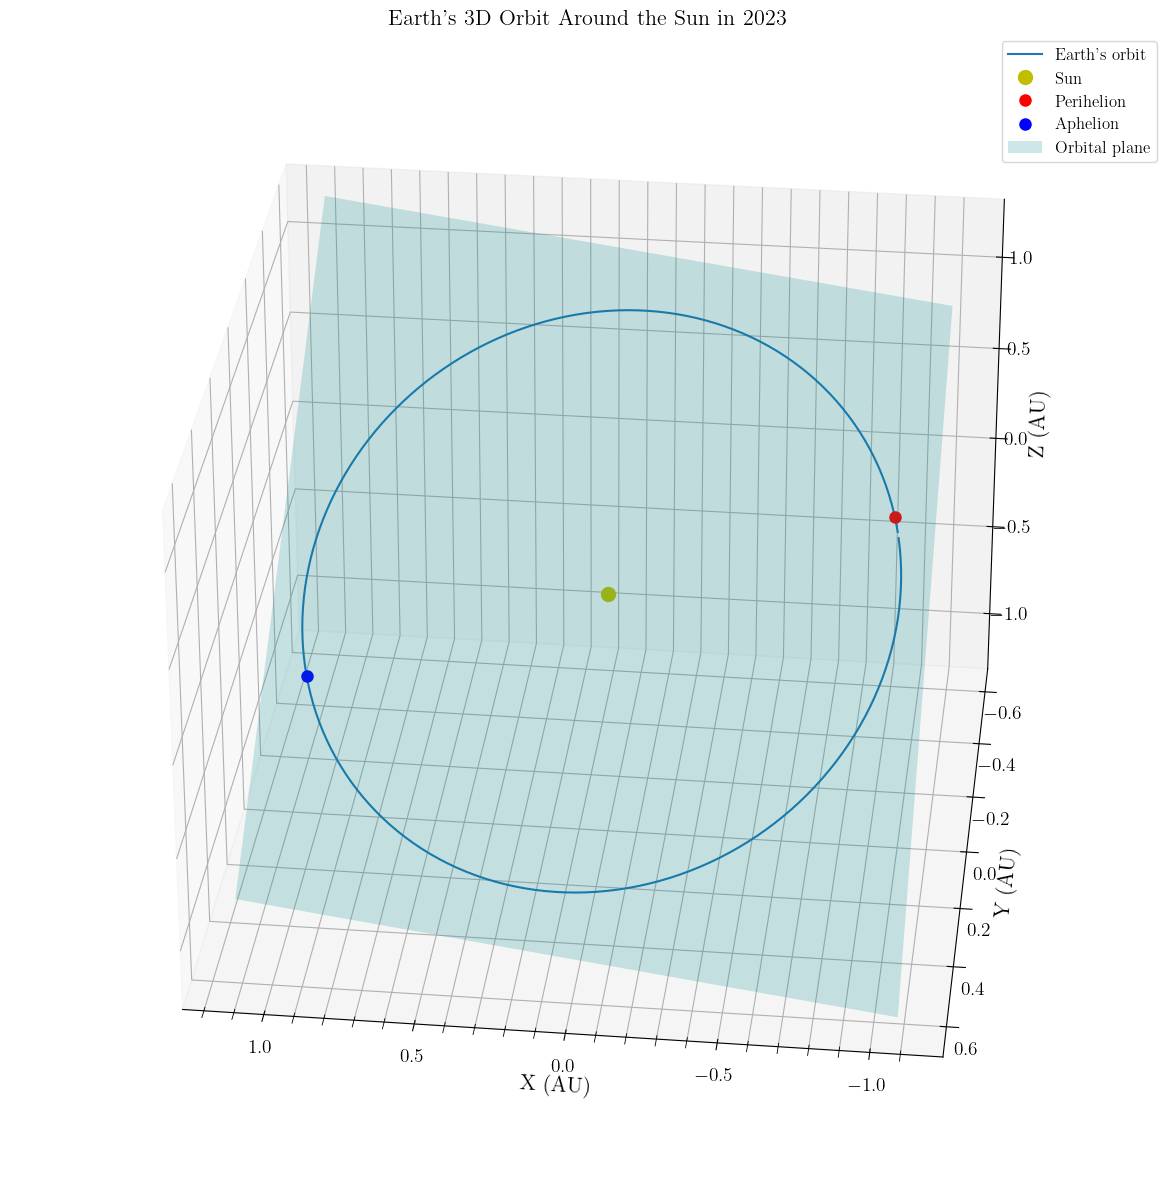

Elevation angle for top-down view: 29.81 degrees
Azimuth angle for top-down view: 96.39 degrees
Perihelion (closest to Sun): 2023-01-04, distance: 0.983290 AU
Aphelion (farthest from Sun): 2023-07-06, distance: 1.016710 AU


In [4]:
def plot_earth_trajectory_3d(year):
    earth_positions = calculate_earth_position(year)
    
    # Extract x, y, and z coordinates
    x = [pos[0] for _, pos in earth_positions]
    y = [pos[1] for _, pos in earth_positions]
    z = [pos[2] for _, pos in earth_positions]
    
    # Calculate distances from Sun
    distances = [np.linalg.norm(pos) for _, pos in earth_positions]
    
    # Find min and max distances
    min_dist_index = np.argmin(distances)
    max_dist_index = np.argmax(distances)
    
    # Create the 3D plot
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the orbit
    ax.plot(x, y, z, label='Earth\'s orbit')
    ax.plot([0], [0], [0], 'yo', markersize=10, label='Sun')
    ax.plot([x[min_dist_index]], [y[min_dist_index]], [z[min_dist_index]], 'ro', markersize=8, label='Perihelion')
    ax.plot([x[max_dist_index]], [y[max_dist_index]], [z[max_dist_index]], 'bo', markersize=8, label='Aphelion')
    
    # Find the normal vector to the orbital plane
    orbital_plane_normal = np.cross([x[0], y[0], z[0]], [x[len(x)//2], y[len(y)//2], z[len(z)//2]])
    orbital_plane_normal = orbital_plane_normal / np.linalg.norm(orbital_plane_normal)
    
    # Create a mesh for the orbital plane
    xx, yy = np.meshgrid(np.linspace(min(x)-0.1, max(x)+0.1, 10),
                         np.linspace(min(y)-0.1, max(y)+0.1, 10))
    d = -orbital_plane_normal[0]*x[0] - orbital_plane_normal[1]*y[0] - orbital_plane_normal[2]*z[0]
    zz = (-orbital_plane_normal[0] * xx - orbital_plane_normal[1] * yy - d) * 1. / orbital_plane_normal[2]
    
    # Plot the orbital plane
    ax.plot_surface(xx, yy, zz, alpha=0.2, color='cyan', label='Orbital plane')
    
    # Set labels and title
    ax.set_xlabel('X (AU)')
    ax.set_ylabel('Y (AU)')
    ax.set_zlabel('Z (AU)')
    ax.set_title(f"Earth's 3D Orbit Around the Sun in {year}")
    
    # Add legend
    ax.legend()
    
    # Calculate elevation and azimuth for top-down view
    elevation = np.arctan2(orbital_plane_normal[2], np.sqrt(orbital_plane_normal[0]**2 + orbital_plane_normal[1]**2))
    azimuth = np.arctan2(orbital_plane_normal[1], orbital_plane_normal[0])
    
    # Convert to degrees
    elev_deg = np.degrees(elevation)
    azim_deg = np.degrees(azimuth)
    
    # Set the view to top-down
    ax.view_init(elev=elev_deg, azim=azim_deg)
    # ax.view_init(elev=elev_deg-20, azim=azim_deg+70)
    
    plt.show()
    

    print(f"Elevation angle for top-down view: {elev_deg:.2f} degrees")
    print(f"Azimuth angle for top-down view: {azim_deg:.2f} degrees")
    print(f"Perihelion (closest to Sun): {earth_positions[min_dist_index][0]}, distance: {distances[min_dist_index]:.6f} AU")
    print(f"Aphelion (farthest from Sun): {earth_positions[max_dist_index][0]}, distance: {distances[max_dist_index]:.6f} AU")


plot_earth_trajectory_3d(year)

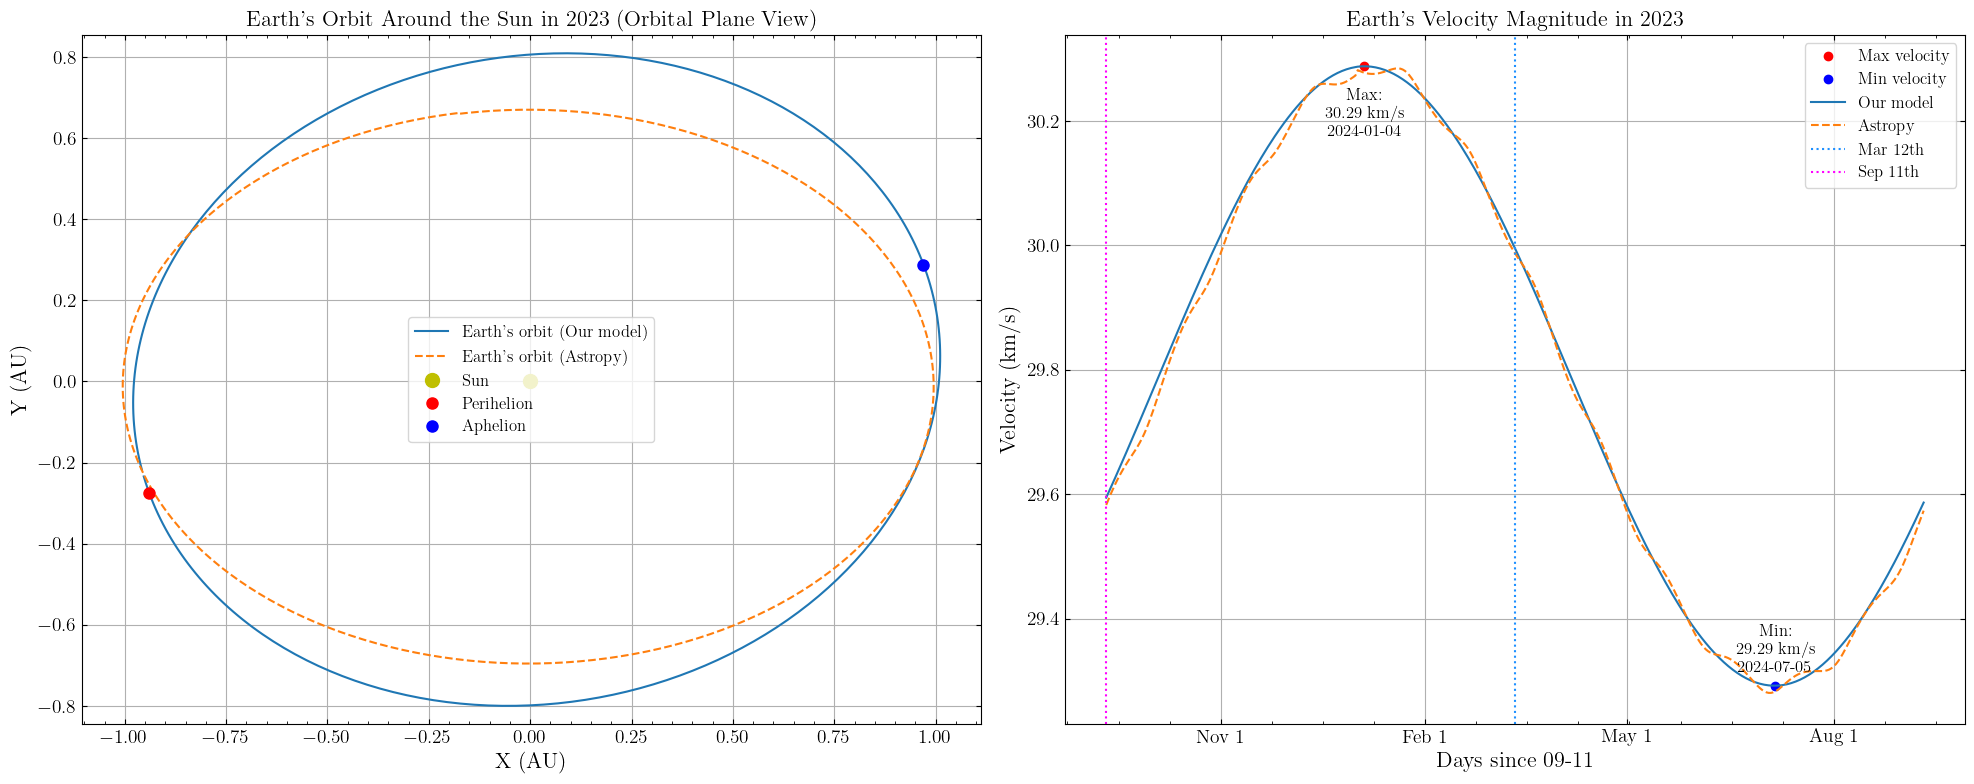

Our model - Maximum velocity: 30.29 km/s on 2024-01-04
Our model - Minimum velocity: 29.29 km/s on 2024-07-05
Astropy - Maximum velocity: 30.28 km/s
Astropy - Minimum velocity: 29.28 km/s


In [5]:
def get_astropy_earth_data(jd_times):
    """
    Get Earth's positions and velocities using Astropy for the given Julian dates.
    
    Parameters:
    -----------
    jd_times : array-like
        Array of Julian dates for which to calculate Earth's position and velocity
    
    Returns:
    --------
    tuple(list, list):
        - List of position vectors in AU
        - List of velocity vectors in km/s
    """
    positions = []
    velocities = []
    
    for jd in jd_times:
        # Get Earth's position and velocity from Astropy
        pos, vel = get_body_barycentric_posvel('earth', Time(jd, format='jd'))
        
        # Convert position to AU (it's already in AU)
        position = [pos.x.value, pos.y.value, pos.z.value]
        
        # Convert velocity to km/s (from AU/day)
        # 1 AU/day = 1731.45683633 km/s
        velocity = [
            vel.x.value * 1731.45683633,
            vel.y.value * 1731.45683633,
            vel.z.value * 1731.45683633
        ]
        
        positions.append(position)
        velocities.append(velocity)
    
    return positions, velocities


def rotate_to_orbital_plane(positions):
    """
    Rotate 3D position vectors to align with Earth's orbital plane.
    Earth's orbital plane is tilted by about 23.44° relative to the ecliptic plane.
    
    Parameters:
    -----------
    positions : list of lists
        List of [x, y, z] position vectors in the original coordinate system
    
    Returns:
    --------
    list:
        List of rotated [x, y, z] vectors where z approximately 0 (in orbital plane)
    """
    # Earth's orbital plane tilt (obliquity) in radians
    epsilon = np.radians(23.44)
    
    # Rotation matrix around x-axis to align with orbital plane
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(epsilon), -np.sin(epsilon)],
        [0, np.sin(epsilon), np.cos(epsilon)]
    ])
    
    # Convert positions to numpy array for easier manipulation
    pos_array = np.array(positions)
    
    # Apply rotation to all positions
    rotated_positions = np.dot(pos_array, Rx.T)
    
    # Convert back to list format
    return rotated_positions.tolist()


def plot_earth_trajectory_and_velocity(year, start_date_str='09-11'):
    """
    Plot Earth's 2D trajectory (in orbital plane) and velocity magnitude side by side, 
    comparing with Astropy data. The velocity plot's x-axis starts from the specified date.
    """
    # Convert start_date_str to datetime object
    start_date = datetime.strptime(f"{year}-{start_date_str}", '%Y-%m-%d')
    
    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    # Calculate Earth's positions and velocities using our model
    earth_positions = calculate_earth_position(year)
    earth_velocities = calculate_earth_velocity(year)
    
    # Generate time points for one year
    num_points = 365
    times = np.linspace(0, Params.yr, num_points)
    jd_times = Time(f'{year}-01-01').jd + times / Params.yr * 365.25
    
    # Get Astropy data for comparison
    astropy_positions, astropy_velocities = get_astropy_earth_data(jd_times)
    
    # Rotate positions to orbital plane view
    positions = [pos for _, pos in earth_positions]
    rotated_positions = rotate_to_orbital_plane(positions)
    rotated_astropy_positions = rotate_to_orbital_plane(astropy_positions)
    
    # Extract data
    x = [pos[0] for pos in rotated_positions]
    y = [pos[1] for pos in rotated_positions]
    x_astropy = [pos[0] for pos in rotated_astropy_positions]
    y_astropy = [pos[1] for pos in rotated_astropy_positions]
    dates = [datetime(year, 1, 1) + timedelta(days=i) for i in range(num_points)]
    velocities = [np.linalg.norm(vel) for _, vel in earth_velocities]
    astropy_velocities_mag = [np.linalg.norm(vel) for vel in astropy_velocities]

    # Create the figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 2D trajectory in orbital plane (left panel)
    ax1.plot(x, y, label="Earth's orbit (Our model)")
    ax1.plot(x_astropy, y_astropy, '--', label="Earth's orbit (Astropy)")
    ax1.plot(0, 0, 'yo', markersize=10, label='Sun')
    
    # Mark perihelion and aphelion
    min_dist_index = np.argmin([np.linalg.norm(pos) for pos in rotated_positions])
    max_dist_index = np.argmax([np.linalg.norm(pos) for pos in rotated_positions])
    ax1.plot(x[min_dist_index], y[min_dist_index], 'ro', markersize=8, label='Perihelion')
    ax1.plot(x[max_dist_index], y[max_dist_index], 'bo', markersize=8, label='Aphelion')
    
    ax1.set_title(f"Earth's Orbit Around the Sun in {year} (Orbital Plane View)")
    ax1.set_xlabel('X (AU)')
    ax1.set_ylabel('Y (AU)')
    ax1.legend()
    ax1.grid(True)
    ax1.axis('equal')
    
    # Plot velocity magnitude (right panel)
    # Shift days to start from the specified date
    shifted_days = [(d - start_date).days % 365 + 1 for d in dates]
    sorted_indices = np.argsort(shifted_days)
    shifted_days = [shifted_days[i] for i in sorted_indices]
    velocities = [velocities[i] for i in sorted_indices]
    astropy_velocities_mag = [astropy_velocities_mag[i] for i in sorted_indices]

    # After sorting velocities and before plotting in ax2
    max_vel_index = np.argmax(velocities)
    min_vel_index = np.argmin(velocities)

    # After plotting velocities in ax2
    ax2.plot(shifted_days[max_vel_index], velocities[max_vel_index], 'ro', label='Max velocity')
    ax2.plot(shifted_days[min_vel_index], velocities[min_vel_index], 'bo', label='Min velocity')

    # Calculate the actual dates for max and min velocities
    max_date = (start_date + timedelta(days=shifted_days[max_vel_index] - 1)).strftime("%Y-%m-%d")
    min_date = (start_date + timedelta(days=shifted_days[min_vel_index] - 1)).strftime("%Y-%m-%d")

    ax2.annotate(
        f'Max: \n{velocities[max_vel_index]:.2f} km/s\n{max_date}',
        (shifted_days[max_vel_index], velocities[max_vel_index]), 
        textcoords="offset points", xytext=(0,-50), ha='center')
    ax2.annotate(
        f'Min: \n{velocities[min_vel_index]:.2f} km/s\n{min_date}',
        (shifted_days[min_vel_index], velocities[min_vel_index]), 
        textcoords="offset points", xytext=(0,+10), ha='center')

    ax2.plot(shifted_days, velocities, label='Our model')
    ax2.plot(shifted_days, astropy_velocities_mag, '--', label='Astropy')
    ax2.set_title(f"Earth's Velocity Magnitude in {year}")
    ax2.set_xlabel("Days since " + start_date_str)
    ax2.set_ylabel("Velocity (km/s)")
    ax2.grid(True)
    
    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']
    ax2.set_xticks(tick_days)
    ax2.set_xticklabels(tick_labels)

    # Add vertical lines for March 12th and September 11th
    march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    ax2.axvline(x=march_12, color='dodgerblue', linestyle=':', label='Mar 12th')
    ax2.axvline(x=sept_11, color='magenta', linestyle=':', label='Sep 11th')

    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    # Print velocity statistics
    print(f"Our model - Maximum velocity: {velocities[max_vel_index]:.2f} km/s on {max_date}")
    print(f"Our model - Minimum velocity: {velocities[min_vel_index]:.2f} km/s on {min_date}")
    print(f"Astropy - Maximum velocity: {max(astropy_velocities_mag):.2f} km/s")
    print(f"Astropy - Minimum velocity: {min(astropy_velocities_mag):.2f} km/s")


plot_earth_trajectory_and_velocity(year, start_date_str='09-11')

### Animations of Sun-Earth dynamics in simulation

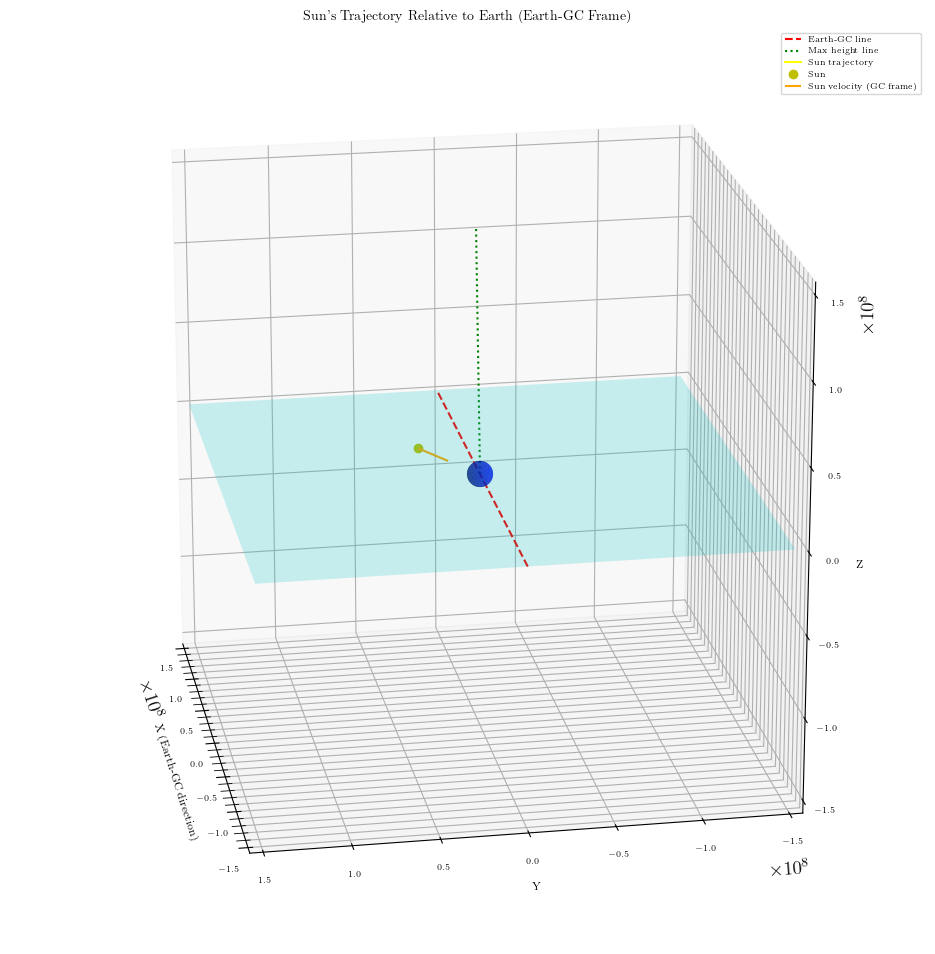

In [6]:
def animate_sun_trajectory(
        sun_positions, sun_velocities, interval=50, subsample=1, save_path=None, freeze_duration=2, elev=30, azim=-60, max_extent=None, dpi=50):
    # Subsample the sun positions and velocities if needed
    positions = sun_positions[::subsample]
    velocities = sun_velocities[::subsample]

    # Calculate the maximum extent of the trajectory
    if max_extent is None:
        max_extent = np.max(np.abs(positions))

    # Scale factor for velocity arrows
    vel_scale = max_extent / np.max(np.linalg.norm(velocities, axis=1)) * 0.2

    # Create a figure with adjusted size
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Adjust the axes position to fill more of the figure
    ax.set_position([0.1, 0.1, 0.8, 0.8])

    # Set axis limits
    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_zlim(-max_extent, max_extent)

    # Set labels with smaller font size
    ax.set_xlabel('X (Earth-GC direction)', fontsize=8)
    ax.set_ylabel('Y', fontsize=8)
    ax.set_zlabel('Z', fontsize=8)
    ax.set_title("Sun's Trajectory Relative to Earth (Earth-GC Frame)", fontsize=10)

    # Reduce tick label size
    ax.tick_params(axis='both', which='major', labelsize=6)

    # Plot Earth as a blue sphere at the center
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    earth_radius = 0.05 * max_extent
    ex = earth_radius * np.outer(np.cos(u), np.sin(v))
    ey = earth_radius * np.outer(np.sin(u), np.sin(v))
    ez = earth_radius * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(ex, ey, ez, color='blue', alpha=0.7)

    # Add Earth-GC line (x-axis)
    ax.plot([-max_extent, max_extent], [0, 0], [0, 0], color='red', linestyle='--', label='Earth-GC line')

    # Plot the ecliptic plane
    xx, yy = np.meshgrid(np.linspace(-max_extent, max_extent, 10), np.linspace(-max_extent, max_extent, 10))
    zz = np.zeros_like(xx)
    ax.plot_surface(xx, yy, zz, alpha=0.2, color='cyan')

    # Find the point with maximum z-coordinate
    max_z_index = np.argmax(positions[:, 2])
    max_z_point = positions[max_z_index]

    # Plot line from origin to max_z_point
    ax.plot([0, max_z_point[0]], [0, max_z_point[1]], [0, max_z_point[2]], color='green', linestyle=':', label='Max height line')

    # Initialize the sun trajectory line and point
    line, = ax.plot([], [], [], color='yellow', label='Sun trajectory')
    point, = ax.plot([], [], [], 'yo', markersize=6, label='Sun')

    # Initialize the velocity arrow (we'll update its data in each frame)
    quiver = ax.quiver(0, 0, 0, 0, 0, 0, color='orange', label='Sun velocity (GC frame)')

    # Set the view angle
    ax.view_init(elev=elev, azim=azim)

    # Ensure equal aspect ratio
    ax.set_box_aspect((1, 1, 1))

    # Reduce legend font size and move it to a less obtrusive position
    ax.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1, 1))

    # Adjust layout
    plt.tight_layout()

    # Animation update function
    def update(frame):
        if frame < len(positions):
            line.set_data(positions[:frame, 0], positions[:frame, 1])
            line.set_3d_properties(positions[:frame, 2])
            point.set_data(positions[frame:frame+1, 0], positions[frame:frame+1, 1])
            point.set_3d_properties(positions[frame:frame+1, 2])
            
            # Update velocity arrow
            quiver.set_segments([[[positions[frame, 0], positions[frame, 1], positions[frame, 2]],
                                  [positions[frame, 0] + velocities[frame, 0] * vel_scale,
                                   positions[frame, 1] + velocities[frame, 1] * vel_scale,
                                   positions[frame, 2] + velocities[frame, 2] * vel_scale]]])
        else:
            # Freeze frame: show the complete trajectory
            line.set_data(positions[:, 0], positions[:, 1])
            line.set_3d_properties(positions[:, 2])
            point.set_data([], [])
            point.set_3d_properties([])
            quiver.set_segments([[[0, 0, 0], [0, 0, 0]]])  # Hide arrow in freeze frame

        return line, point, quiver

    # Calculate total frames (including freeze frames)
    total_frames = len(positions) + int(freeze_duration * 1000 / interval)

    # Create the animation
    anim = FuncAnimation(fig, update, frames=total_frames, interval=interval, blit=False, repeat=False)

    if save_path:
        # Save the animation with higher DPI
        anim.save(save_path, writer='pillow', fps=1000//interval, dpi=dpi)
    else:
        # Show the plot
        plt.show()

    return anim


def SunEarthGC_frame_coords_local(year):
    """
    Calculate coordinates and velocities in a frame aligned with the Galactic Center,
    using get_body_barycentric_posvel for more accurate Earth velocities.
    """
    # Define the Galactic Center coordinates
    gc = SkyCoord(l=0*apu.degree, b=0*apu.degree, frame='galactic')
    
    # Sun's velocity w.r.t. CNB in galactic coordinates/frame (km/s)
    sun_vel_CNB = np.array([-0.06935679, -0.66222051, 0.74609224]) * 369.82

    # Sun's velocity w.r.t. MWGC in galactic coordinates/frame (km/s)
    sun_vel_MW = np.array([11.1029257, 250.8323298, 7.3656565])
    
    sun_vel_Gal = sun_vel_MW

    # Lists for Sun's positions and velocities, and Earth's velocities
    sun_positions = []
    sun_vels = []
    earth_vels = []
    
    # Loop backwards through each day of the year
    for day in range(365, 0, -1):  
        # Time object of current day at noon UTC
        time = Time(f'{year}-12-31 12:00:00') - (365-day)*apu.day
        
        # Get Earth's position and velocity using get_body_barycentric_posvel
        earth_pos, earth_vel = get_body_barycentric_posvel('earth', time)
        
        # Convert Earth's velocity from AU/day to km/s
        earth_vel_icrs = np.array([
            earth_vel.x.value,
            earth_vel.y.value,
            earth_vel.z.value
        ]) * 1731.45683633  # conversion factor from AU/day to km/s
        
        # Get Sun's position in GCRS coordinates (relative to Earth) in km
        sun_gcrs = SkyCoord(
            get_body_barycentric('sun', time), 
            frame='icrs').transform_to(GCRS(obstime=time))
        sun_vector = sun_gcrs.cartesian.xyz.to(apu.km).value
        
        # Transform the Galactic Center to GCRS
        gc_gcrs = gc.transform_to(GCRS(obstime=time))
        
        # Calculate the unit vector pointing from Earth to Galactic Center
        gc_vector = gc_gcrs.cartesian.xyz.value
        gc_unit_vector = gc_vector / np.linalg.norm(gc_vector)
        
        # Define the new coordinate system
        x_axis = gc_unit_vector
        z_axis = np.cross(x_axis, [0, 0, 1])
        z_axis = z_axis / np.linalg.norm(z_axis)
        y_axis = np.cross(z_axis, x_axis)
        
        # Create rotation matrix
        rotation_matrix = np.column_stack((x_axis, y_axis, z_axis))
        
        # Rotate Sun's position and velocity into new coordinate system
        sun_rotated = np.dot(rotation_matrix.T, sun_vector)
        sun_vel_rotated = np.dot(rotation_matrix.T, sun_vel_Gal)
        
        # Rotate Earth's velocity into the new coordinate system (km/s)
        earth_vel_rotated = np.dot(rotation_matrix.T, earth_vel_icrs)
        
        # Calculate Earth's velocity relative to CMB in the rotated frame (km/s)
        earth_vel_rotated = sun_vel_rotated + earth_vel_rotated
        
        # Append the rotated position and velocities to the lists
        sun_positions.append(sun_rotated)
        sun_vels.append(sun_vel_rotated)
        earth_vels.append(earth_vel_rotated)
    
    # note: sun_positions: km units ; velocities: km/s units
    return np.array(sun_positions), np.array(sun_vels), np.array(earth_vels)


# Sun's trajectory animated in special Earth-GC frame for each day of year 2024
year = 2024
# sun_positions, sun_velocities, _ = SimPlot.SunEarthGC_frame_coords(year)
sun_positions, sun_velocities, _ = SunEarthGC_frame_coords_local(year)
animate_sun_trajectory(
    sun_positions, 
    sun_velocities,
    interval=50, 
    subsample=5, 
    save_path='sun_trajectory_animation_with_GC_vel_arrow.gif', 
    freeze_duration=0.01, 
    elev=20, 
    azim=170,
    dpi=300
)

## Recreating Safdi et al. (2014)

### Functions 3D integration (perhaps still useful later)

In [7]:
# @jax.jit
def f_distr_3D(v_range, t_index, bound, v_0):

    def bound_case(_):

        # Get x,y,z coordinates for velocity range
        v_nu = Utils.v_mag_to_xyz(v_range, Params.key)

        # Make velocity combination for f(v)
        r_s = earth_positions[t_index]
        v_s = v_nu + earth_velocities[t_index]
        v_inf = v_infinity(v_s, r_s)
        v_for_f = v_CNB + v_inf

        # Calculate the magnitude of v_for_f
        v_for_f_mag = jnp.linalg.norm(v_for_f, axis=-1)

        # Create a meshgrid for v_x, v_y, v_z of v_for_f
        mesh_v_range = jnp.linspace(
            -jnp.max(v_for_f_mag), jnp.max(v_for_f_mag), mesh_num)
        v_x, v_y, v_z = jnp.meshgrid(
            mesh_v_range, mesh_v_range, mesh_v_range, indexing='xy')

        # Create the mask
        # mask = v_for_f_mag < v_esc_MW
        mask = jnp.sqrt(v_x**2 + v_y**2 + v_z**2) < v_esc_MW

        # Calculate the distribution
        exp_term = jnp.exp(-(v_x**2 + v_y**2 + v_z**2) / v_0**2)
        f_v = jnp.where(
            mask, 
            jnp.power(jnp.pi * v_0**2, -3/2) * exp_term, 
            jnp.zeros_like(exp_term)
        )

        # Normalize
        z = v_esc_MW / v_0
        N_esc = jsp.special.erf(z) - 2 / jnp.sqrt(jnp.pi) * z * jnp.exp(-z**2)
        f_v_normalized = f_v / N_esc

        return f_v_normalized, mesh_v_range

    def unbound_case(_):
        # Implementation for unbound case
        return jnp.zeros((mesh_num,mesh_num,mesh_num)), jnp.zeros((mesh_num))

    f_v = jax.lax.cond(bound, bound_case, unbound_case, operand=None)

    return f_v

# @jax.jit
def number_density_3D(t_index, m_nu, bound, v_0):
    """Calculate the neutrino number density at time t (a certain day)."""

    p_range = jnp.geomspace(0.01, 100, 1000) * Params.T_CNB
    v_range = p_range / m_nu
    v_max = 100*Params.T_CNB / m_nu
    mesh_v_range = jnp.linspace(-v_max, v_max, mesh_num)

    def bound_case(_):
        
        # Get 3D velocity distribution
        f_v, int_v_range = f_distr_3D(v_range, t_index, bound, v_0)
        
        # Integrate over 3D velocity sphere
        integral_over_z = trap(f_v, int_v_range, axis=-1)
        integral_over_yz = trap(integral_over_z, int_v_range, axis=-1)
        integral_over_xyz = trap(integral_over_yz, int_v_range, axis=-1)
        
        # Compute and return number density        
        return integral_over_xyz / (2*jnp.pi)**3

    def unbound_case(_):
        integrand = p_range**3 * f_distr(v_range, t_index, m_nu, bound, v_0)
        integral = trap(integrand, x=jnp.log(v_range))
        nu_dens = integral/(2*jnp.pi**2)/Params.cm**-3
        return nu_dens
    
    nu_dens = jax.lax.cond(bound, bound_case, unbound_case, operand=None)

    return nu_dens


### Computing density arrays (run Safdi.py though!)

(366, 3) (366, 3)


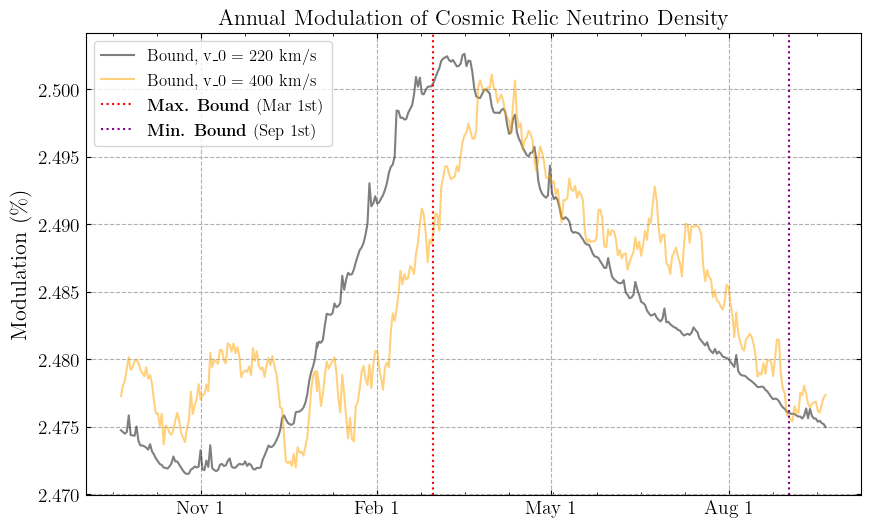

In [ ]:
# Get Earth's positions and velocities
earth_positions = jnp.array(
    [pos for _, pos in calculate_earth_position(year)])*Params.AU
earth_velocities = jnp.array(
    [vel for _, vel in calculate_earth_velocity(year)])*Params.km/Params.s
print(earth_positions.shape, earth_velocities.shape)
# print(earth_positions[0], jnp.linalg.norm(earth_velocities[0]))

# Generate time points for one year
times = jnp.linspace(0, Params.yr, 365)
jd_times = Time('2023-01-01').jd + times / Params.yr * 365

# Sun's velocity in CNB(==CMB) frame
v_CNB = jnp.array([-0.0695, -0.662, 0.747])*369*Params.km/Params.s

# Approximate escape velocity for MW
v_esc_MW = 550*Params.km/Params.s

# Sun's velocity in Galactic frame
v_Sun = jnp.array([11, 232, 7])*Params.km/Params.s


@jax.jit
def v_infinity(v_s, r_s):
    """
    Calculate the initial Solar-frame velocity for particles, s.t. they have velocity v_s at Earth's location.
    """
    
    v_GM = 2*Params.G*Params.Msun/jnp.linalg.norm(r_s, axis=-1)
    v_inf2 = jnp.linalg.norm(v_s, axis=-1)**2 - v_GM
    v_inf = jnp.sqrt(jnp.maximum(0, v_inf2))
    # v_inf = jnp.sqrt(v_inf2)
    r_s_unit = r_s / jnp.linalg.norm(r_s, axis=-1)
    vr_s_dot = jnp.dot(v_s, r_s_unit)

    numer = v_inf2[..., None]*v_s + v_inf[..., None]*v_GM/2*r_s_unit - v_inf[..., None]*v_s*vr_s_dot[..., None]
    denom = v_inf2 + v_GM/2 - v_inf*vr_s_dot
    
    return numer / denom[..., None]


@jax.jit
def f_distr(v_range, t_index, m_nu, bound, v_0):
    """Phase-space distribution at Earth's location."""

    # Get x,y,z coords.
    v_nu = Utils.v_mag_to_xyz(v_range, Params.key)

    # Compute v_inf and v argument as used for f(v)
    r_s = earth_positions[t_index]
    v_s = v_nu + earth_velocities[t_index]
    v_inf = v_infinity(v_s, r_s)

    def bound_case(_):

        v_for_f = v_inf + v_Sun
        v_for_f_mag = jnp.linalg.norm(v_for_f, axis=-1)

        # Create mask for velocity magnitudes smaller than escape velocity
        mask = v_for_f_mag < v_esc_MW

        # Compute standard halo model (SHM) distribution
        exp_term = jnp.exp(-v_for_f_mag**2/v_0**2)
        f_v = jnp.where(
            mask, 
            jnp.power(jnp.pi*v_0**2, -3/2) * exp_term, 
            jnp.zeros_like(exp_term))
        
        # Normalisation constant, and normalised velocity distribution
        z = v_esc_MW/v_0
        N_esc = jsp.special.erf(z) - 2/jnp.sqrt(jnp.pi)*z*jnp.exp(-z**2)
        f_v_normalized = f_v / N_esc

        return Params.N0 * m_nu**3 * f_v_normalized
        # return f_v_normalized

    def unbound_case(_):

        v_for_f = v_inf + v_CNB
        v_for_f_mag = jnp.linalg.norm(v_for_f, axis=-1)

        f_v = m_nu**3/(jnp.exp(m_nu*v_for_f_mag/Params.T_CNB)+1)

        return f_v

    f_v = jax.lax.cond(bound, bound_case, unbound_case, operand=None)

    return f_v

@jax.jit
def number_density(t_index, m_nu, bound, v_0):
    """Calculate the neutrino number density at time t (a certain day)."""

    # note: below reso of (0.001, 100, 100_000), curves are wonky
    # note: for (0.001, 1000, 1_000_000) we get similar curves as in Safdi+
    p_range = jnp.geomspace(0.001, 1000, 100_000) * Params.T_CNB
    v_range = p_range / m_nu

    def bound_case(_):
        
        f_v = f_distr(v_range, t_index, m_nu, bound, v_0)
        integrand = v_range**3 * f_v
        integral = trap(integrand, x=jnp.log(v_range), axis=-1)
        nu_dens_cm3 = 4*jnp.pi*integral/Params.cm**-3
        return nu_dens_cm3

    def unbound_case(_):

        f_v = f_distr(v_range, t_index, m_nu, bound, v_0)
        integrand = v_range**3 * f_v
        integral = trap(integrand, x=jnp.log(v_range), axis=-1)
        nu_dens_cm3 = integral/(2*jnp.pi**2)/Params.cm**-3
        return nu_dens_cm3
    
    nu_dens = jax.lax.cond(bound, bound_case, unbound_case, operand=None)

    return nu_dens

#! CAUTION: requires high memory capacity, if p_range is high resolution
@jax.jit
def calculate_modulation_parallel(m_nu, bound, v_0):
    """Calculate the fractional modulation throughout the year."""

    # nu_dens_fctn = lambda t_idx: number_density_3D(t_idx, m_nu, bound, v_0)
    nu_dens_fctn = lambda t_idx: number_density(t_idx, m_nu, bound, v_0)
    densities = jax.vmap(nu_dens_fctn)(jnp.arange(len(times)))

    min_density = jnp.min(densities)
    mod = (densities - min_density) / (densities + min_density) * 100

    # return times, mod
    return times, densities

@jax.jit
def calculate_modulation(m_nu, bound, v_0):
    """Calculate the fractional modulation throughout the year."""
    
    num_days = len(times)
    densities = jnp.zeros(num_days)
    
    def body_fun(i, densities):
        density = number_density(i, m_nu, bound, v_0)
        return densities.at[i].set(density)
    
    densities = jax.lax.fori_loop(0, num_days, body_fun, densities)
    
    min_density = jnp.min(densities)
    mod = (densities - min_density) / (densities + min_density) * 100
    
    return times, densities
    # return times, mod


def plot_modulations(which, start_date_str='09-11'):
    """Plot the fractional modulations for different scenarios."""
    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')
    
    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    m_nu_light = 0.15 * Params.eV
    m_nu_heavy = 0.35 * Params.eV
    
    cases = [
        (m_nu_light, False, 220*Params.km/Params.s, 'Unbound, 0.15 eV', 'dashed', 'purple', 0.5),
        (m_nu_heavy, False, 220*Params.km/Params.s, 'Unbound, 0.35 eV', 'dashed', 'blue', 0.5),
        (m_nu_heavy, True, 220*Params.km/Params.s, 'Bound, v_0 = 220 km/s', 'solid', 'black', 0.5),
        (m_nu_heavy, True, 400*Params.km/Params.s, 'Bound, v_0 = 400 km/s', 'solid', 'orange', 0.5)
    ]

    if which == "unbound":
        scenarios = cases[:2]
    elif which == "bound":
        scenarios = cases[2:]
    elif which == "both":
        scenarios = cases

    for m_nu, bound, v_0, label, linestyle, color, alpha in scenarios:
        days, mod = calculate_modulation(m_nu, bound, v_0)

        # Check if all elements are zero
        if jnp.all(mod == 0):
            print("all zeros")

        # Check if all elements are nan
        if jnp.all(jnp.isnan(mod)):
            print("all nan")

        # Shift days to start from the specified date
        shifted_days = (days/Params.yr*365 - start_day_of_year) % 365 + 1
        sorted_indices = jnp.argsort(shifted_days)
        shifted_days = shifted_days[sorted_indices]
        mod = mod[sorted_indices]

        ax.plot(
            shifted_days, mod, 
            linestyle=linestyle, color=color, label=label, alpha=alpha)

    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]

    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']

    plt.xticks(tick_days, tick_labels)

    # Set y-axis limits
    # plt.ylim(0, 3)

    plt.title('Annual Modulation of Cosmic Relic Neutrino Density')
    plt.ylabel(r'Modulation ($\%$)')
    plt.grid(True, which="major", linestyle="dashed")
    
    if which == "unbound" or which == "both":
        # Add vertical lines for ~March 12th and ~September 11th
        march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
        sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1

        plt.axvline(
            x=march_12, color='dodgerblue', linestyle=':', 
            label=r'$\textbf{Min. Unbound}$ (Mar 12th)')
        plt.axvline(
            x=sept_11, color='magenta', linestyle=':', 
            label=r'$\textbf{Max. Unbound}$ (Sep 11th)')
        
    if which == "bound" or which == "both":
        # Add vertical lines for ~March 1st and ~September 1st
        march_1 = (datetime_date(2000, 3, 1) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
        sept_1 = (datetime_date(2000, 9, 1) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1

        # Plot the vertical lines
        plt.axvline(
            x=march_1, color='red', linestyle=':', 
            label=r'$\textbf{Max. Bound}$ (Mar 1st)')
        plt.axvline(
            x=sept_1, color='purple', linestyle=':', 
            label=r'$\textbf{Min. Bound}$ (Sep 1st)')


    plt.legend(prop={"size":12})

    plt.savefig(
        f"{fig_folder}/modulation_1year_Earth_frame_{start_date_str}start_FD.pdf",
        bbox_inches="tight")

    plt.show()
    plt.close()

mesh_num = 50
# Run the function with a specific start date
# plot_modulations(which="unbound", start_date_str='09-20')
plot_modulations(which="bound", start_date_str='09-20')
# plot_modulations(which="both", start_date_str='09-20')

### Tests & Validations

#### Maxwell velocity distr. (SMH) integrating to 1

In [9]:
def maxwell_f(v_mag, v_0, v_esc):

    mask = v_mag < v_esc
    f_v = jnp.where(
        mask, 
        jnp.power(jnp.pi*v_0**2, -3/2) * jnp.exp(-v_mag**2/v_0**2), 
        0.0)
    z = v_esc/v_0
    N_esc = jsp.special.erf(z) - 2/jnp.sqrt(jnp.pi)*z*jnp.exp(-z**2)
    f_v_normalized = f_v / N_esc

    return f_v_normalized

p_range = jnp.geomspace(0.01, 10, 1000)*Params.T_CNB
v_unit = Params.km/Params.s
v_range = p_range / 0.35

f_v_norm = maxwell_f(v_range, 220*v_unit, 550*v_unit)
f_int = trap(v_range**3*f_v_norm, x=jnp.log(v_range))
print(4*jnp.pi*f_int)

0.9999044072032583


#### 1D (isotropic) integration of $f_{\rm FD}(\vec{v}_\nu)$

In [10]:
m_nu = 0.35*Params.eV
p_range = jnp.geomspace(0.01, 10, 1000)*Params.T_CNB
v_range = p_range / m_nu


def fermi_dirac_mom(p):
    return 1/(jnp.exp(p/Params.T_CNB)+1)

f_FD_p = fermi_dirac_mom(p_range)
f_int_p = trap(p_range**3*f_FD_p, x=jnp.log(p_range))
print(f"1D number density (p): {f_int_p/(2*jnp.pi**2)/Params.cm**-3:5f} cm^-3")


def fermi_dirac_vel(m, v):
    return m**3/(jnp.exp(m*v/Params.T_CNB)+1)

f_FD_v = fermi_dirac_vel(m_nu, v_range)

f_int_v = trap(v_range**3*f_FD_v, x=jnp.log(v_range))
print(f"1D number density (v): {f_int_v/(2*jnp.pi**2)/Params.cm**-3:5f} cm^-3")

1D number density (p): 56.435186 cm^-3
1D number density (v): 56.435186 cm^-3


#### 3D integration of $f_{\rm FD}(\vec{v}_\nu)$

In [11]:
@jax.jit
def fermi_dirac_vel(m, v_x, v_y, v_z):
    v = jnp.sqrt(v_x**2 + v_y**2 + v_z**2)
    return m**3 / (jnp.exp(m*v/Params.T_CNB) + 1)

@jax.jit
def number_density_3d(m_nu, v_max):
    
    # We can use the (+/-) max velocity magnitudes to create the ranges for the 
    # x,y,z components, because accounting for the whole velocity sphere means 
    # that the extremes would be that e.g. the x-direction has the total 
    # (+ or -) value of the magnitude already, whereas y-, and z- are 0. And so 
    # for all the other extreme cases. Then the mesh grid accounts for all 
    # x,y,z combinations.
    mesh_num = 500
    mesh_v = jnp.linspace(-v_max, v_max, mesh_num)
    v_x, v_y, v_z = jnp.meshgrid(mesh_v, mesh_v, mesh_v, indexing='xy')

    f_FD_v = fermi_dirac_vel(m_nu, v_x, v_y, v_z)
    print(f_FD_v.shape)

    # Perform the 3D integration
    integral_over_z = trap(f_FD_v, mesh_v, axis=-1)
    integral_over_yz = trap(integral_over_z, mesh_v, axis=-1)
    integral_over_xyz = trap(integral_over_yz, mesh_v, axis=-1)
    
    return integral_over_xyz / (2*jnp.pi)**3
    

# Parameters
m_nu = 0.35*Params.eV
v_max = 100*Params.T_CNB / m_nu

# Compute number density using 3D integration
n_3d = number_density_3d(m_nu, v_max)
print(f"3D number density: {n_3d/Params.cm**-3:5f} cm^-3")
n_3d /= Params.N0
print(f"normalised: {n_3d}")
#? so by density "rho" they actually mean the number density?

(500, 500, 500)
3D number density: 56.608112 cm^-3
normalised: 0.9999821716736966


Adding any constant velocities here, as e.g. $f_{\rm FD}(\vec{v}_\nu + \vec{v}_{\rm CMB} + \vec{V}_\oplus(t))$, will technically not affect the number density, as the integration over each axis ideally goes from -inf to inf. So shifting the v_range will not affect anything. Of course that's hard to demonstrate numerically though, as it would require very large mesh range and dense sampling.

See cell below for attempt.

In [12]:
@jax.jit
def fermi_dirac_vel(m, v_x, v_y, v_z):
    v = jnp.sqrt(v_x**2 + v_y**2 + v_z**2)
    return m**3 / (jnp.exp(m*v/Params.T_CNB) + 1)

@jax.jit
def number_density_3d(t_index, m_nu, v_max):

    mesh_num = 500
    mesh_v = jnp.linspace(-v_max, v_max, mesh_num)
    v_x, v_y, v_z = jnp.meshgrid(mesh_v, mesh_v, mesh_v, indexing='xy')

    # Add constant velocities
    v_x += v_CNB[0] + earth_velocities[t_index,0]
    v_y += v_CNB[1] + earth_velocities[t_index,1]
    v_z += v_CNB[2] + earth_velocities[t_index,2]

    f_FD_v = fermi_dirac_vel(m_nu, v_x, v_y, v_z)

    # Perform the 3D integration
    integral_over_z = trap(f_FD_v, mesh_v, axis=-1)
    integral_over_yz = trap(integral_over_z, mesh_v, axis=-1)
    integral_over_xyz = trap(integral_over_yz, mesh_v, axis=-1)
    
    return integral_over_xyz / (2*jnp.pi)**3
    

# Parameters
m_nu = 0.35*Params.eV
v_max = 100*Params.T_CNB / m_nu

# Compute number density using 3D integration
for t_index in (1, 45, 90, 135, 180, 225, 270):
    n_3d = number_density_3d(t_index, m_nu, v_max)
    print(f"3D n_nu (day {t_index}): {n_3d/Params.cm**-3:5f} cm^-3 (norm: {n_3d/Params.N0:6f})")

3D n_nu (day 1): 56.609684 cm^-3 (norm: 1.000010)
3D n_nu (day 45): 56.608450 cm^-3 (norm: 0.999988)
3D n_nu (day 90): 56.608525 cm^-3 (norm: 0.999989)
3D n_nu (day 135): 56.608700 cm^-3 (norm: 0.999993)
3D n_nu (day 180): 56.609107 cm^-3 (norm: 1.000000)
3D n_nu (day 225): 56.608806 cm^-3 (norm: 0.999994)
3D n_nu (day 270): 56.608628 cm^-3 (norm: 0.999991)


### Modulation plotting function

In [ ]:
def plot_modulations_from_arrays(
        which, density_arrays, cases, start_date_str='09-11', 
        y_lims=None, pdf_str='mod.pdf'):
    """
    Plot the modulations using pre-computed density arrays.
    
    Parameters:
    -----------
    which : str
        'unbound', 'bound', or 'both'
    density_arrays : dict
        Dictionary containing the density arrays, with keys matching the cases
        For unbound: f"annual_densities_{m_nu}eV_unbound.npy"
        For bound: f"annual_densities_{v_0}kms_bound.npy"
    cases : list
        List of tuples containing (m_nu, bound, v_0, label, linestyle, color, alpha)
    start_date_str : str
        Start date in format 'MM-DD'
    """

    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')
    start_day_of_year = start_date.timetuple().tm_yday

    # Filter cases based on which
    if which == "unbound":
        scenarios = [case for case in cases if not case[1]]  # bound is False
    elif which == "bound":
        scenarios = [case for case in cases if case[1]]      # bound is True
    elif which == "both":
        scenarios = cases

    # Generate time points
    days = jnp.linspace(0, Params.yr, 365)

    for m_nu, bound, v_0, label, linestyle, color, alpha in scenarios:
        # Load the appropriate density array
        if not bound:
            key = f"annual_densities_{m_nu}eV_unbound"
        else:
            key = f"annual_densities_{v_0/(Params.km/Params.s)}kms_{m_nu}eV_bound"
        
        densities = density_arrays[key]

        # Calculate modulation
        min_density = jnp.min(densities)
        mod = (densities - min_density) / (densities + min_density) * 100
        mod = densities

        # Check if all elements are zero or nan
        if jnp.all(mod == 0):
            print("all zeros")
        if jnp.all(jnp.isnan(mod)):
            print("all nan")

        # Shift days to start from the specified date
        shifted_days = (days/Params.yr*365 - start_day_of_year) % 365 + 1
        sorted_indices = jnp.argsort(shifted_days)
        shifted_days = shifted_days[sorted_indices]
        mod = mod[sorted_indices]

        ax.plot(
            shifted_days, mod, 
            linestyle=linestyle, color=color, label=label, alpha=alpha)

    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                 datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 
                 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']
    plt.xticks(tick_days, tick_labels)

    plt.title(r'Solar Modulation of C$\nu$B Density')
    plt.ylabel(r'Modulation ($\%$)')
    plt.grid(True, which="major", linestyle="dashed")

    # Axis limits
    if y_lims is not None:
        plt.ylim(y_lims[0], y_lims[1])
    
    if which == "unbound" or which == "both":
        march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
        sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
        plt.axvline(x=march_12, color='dodgerblue', linestyle=':', 
                   label=r'$\textbf{Min. Unbound}$ (Mar 12th)')
        plt.axvline(x=sept_11, color='magenta', linestyle=':', 
                   label=r'$\textbf{Max. Unbound}$ (Sep 11th)')
        
    if which == "bound" or which == "both":
        march_1 = (datetime_date(2000, 3, 1) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
        sept_1 = (datetime_date(2000, 9, 1) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
        plt.axvline(x=march_1, color='red', linestyle=':', 
                   label=r'$\textbf{Max. Bound}$ (Mar 1st)')
        plt.axvline(x=sept_1, color='purple', linestyle=':', 
                   label=r'$\textbf{Min. Bound}$ (Sep 1st)')

    plt.legend(prop={"size":10})
    plt.show()
    plt.savefig(f"{fig_folder}/{pdf_str}", bbox_inches="tight")
    plt.close()


### Plots: unbound only (densities)

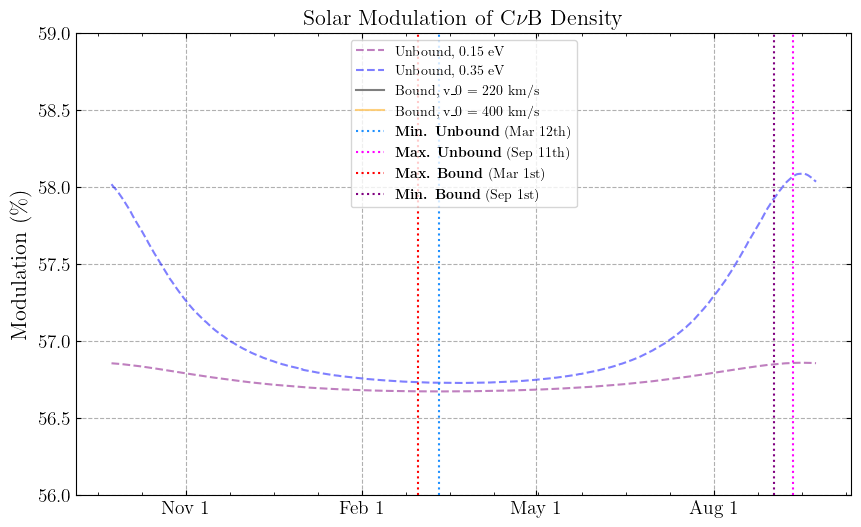

In [14]:
# Light and heavy mass
m_l = 0.15*Params.eV
m_h = 0.35*Params.eV

cases = [
    (m_l, False, 220.0*Params.km/Params.s, f'Unbound, {m_l} eV', 'dashed', 'purple', 0.5),
    (m_h, False, 220.0*Params.km/Params.s, f'Unbound, {m_h} eV', 'dashed', 'blue', 0.5),
    (m_h, True, 220.0*Params.km/Params.s, 'Bound, v_0 = 220 km/s', 'solid', 'black', 0.5),
    (m_h, True, 400.0*Params.km/Params.s, 'Bound, v_0 = 400 km/s', 'solid', 'orange', 0.5)
]
density_arrays = {
    f"annual_densities_{m_l}eV_unbound": jnp.load(f"annual_densities_{m_l}eV_unbound.npy"),
    f"annual_densities_{m_h}eV_unbound": jnp.load(f"annual_densities_{m_h}eV_unbound.npy"),
    f"annual_densities_220.0kms_{m_h}eV_bound": jnp.load(f"annual_densities_220.0kms_{m_h}eV_bound.npy"),
    f"annual_densities_400.0kms_{m_h}eV_bound": jnp.load(f"annual_densities_400.0kms_{m_h}eV_bound.npy")
}

plot_modulations_from_arrays(
    "both", density_arrays, cases, start_date_str='09-23', 
    # y_lims=(0.0, 1.25),
    y_lims=(56.0, 59.0),
    # y_lims=None,
    pdf_str=f"modulation_{m_l}eV_{m_h}eV.pdf")

### Plots: bound only (densities)

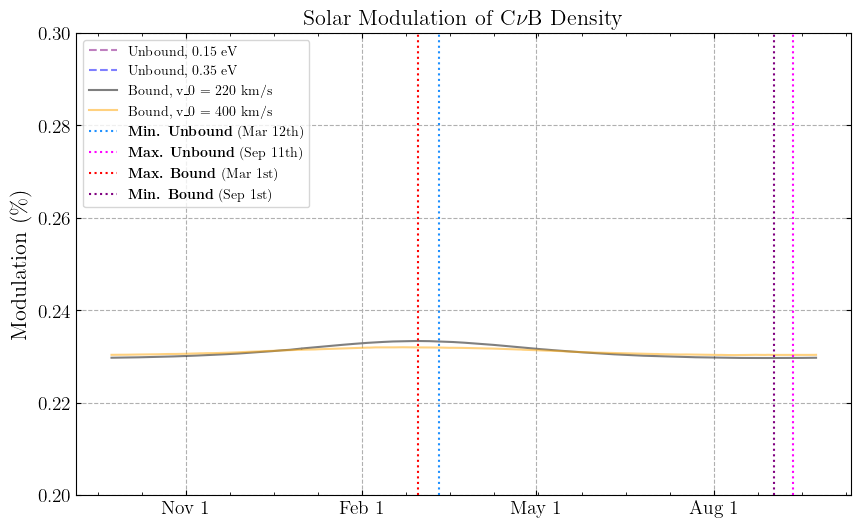

In [15]:
# Light and heavy mass
m_l = 0.15*Params.eV
m_h = 0.35*Params.eV

cases = [
    (m_l, False, 220.0*Params.km/Params.s, f'Unbound, {m_l} eV', 'dashed', 'purple', 0.5),
    (m_h, False, 220.0*Params.km/Params.s, f'Unbound, {m_h} eV', 'dashed', 'blue', 0.5),
    (m_h, True, 220.0*Params.km/Params.s, 'Bound, v_0 = 220 km/s', 'solid', 'black', 0.5),
    (m_h, True, 400.0*Params.km/Params.s, 'Bound, v_0 = 400 km/s', 'solid', 'orange', 0.5)
]
density_arrays = {
    f"annual_densities_{m_l}eV_unbound": jnp.load(f"annual_densities_{m_l}eV_unbound.npy"),
    f"annual_densities_{m_h}eV_unbound": jnp.load(f"annual_densities_{m_h}eV_unbound.npy"),
    f"annual_densities_220.0kms_{m_h}eV_bound": jnp.load(f"annual_densities_220.0kms_{m_h}eV_bound.npy"),
    f"annual_densities_400.0kms_{m_h}eV_bound": jnp.load(f"annual_densities_400.0kms_{m_h}eV_bound.npy")
}

plot_modulations_from_arrays(
    "both", density_arrays, cases, start_date_str='09-23', 
    y_lims=(0.2, 0.3),
    pdf_str=f"modulation_{m_l}eV_{m_h}eV.pdf")

### Plots: combined (modulations)

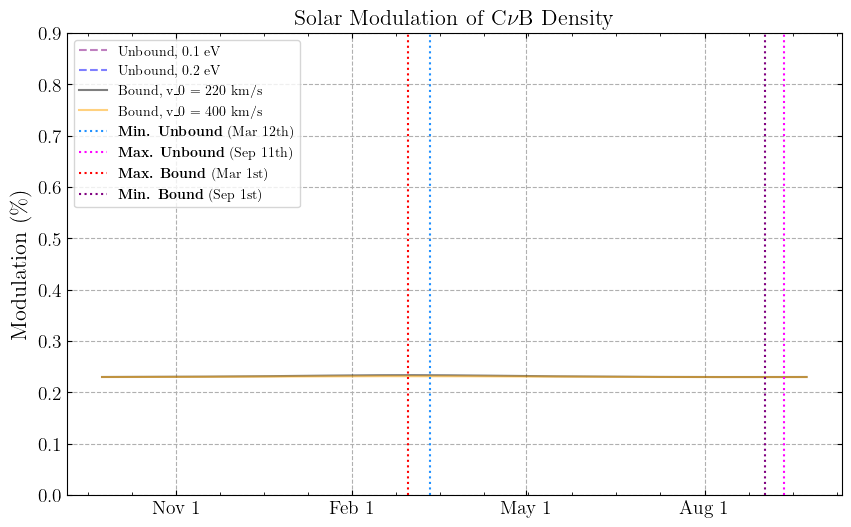

In [16]:
# Light and heavy mass
m_l = 0.1*Params.eV
m_h = 0.2*Params.eV

cases = [
    (m_l, False, 220.0*Params.km/Params.s, f'Unbound, {m_l} eV', 'dashed', 'purple', 0.5),
    (m_h, False, 220.0*Params.km/Params.s, f'Unbound, {m_h} eV', 'dashed', 'blue', 0.5),
    (m_h, True, 220.0*Params.km/Params.s, 'Bound, v_0 = 220 km/s', 'solid', 'black', 0.5),
    (m_h, True, 400.0*Params.km/Params.s, 'Bound, v_0 = 400 km/s', 'solid', 'orange', 0.5)
]
density_arrays = {
    f"annual_densities_{m_l}eV_unbound": jnp.load(f"annual_densities_{m_l}eV_unbound.npy"),
    f"annual_densities_{m_h}eV_unbound": jnp.load(f"annual_densities_{m_h}eV_unbound.npy"),
    f"annual_densities_220.0kms_{m_h}eV_bound": jnp.load(f"annual_densities_220.0kms_{m_h}eV_bound.npy"),
    f"annual_densities_400.0kms_{m_h}eV_bound": jnp.load(f"annual_densities_400.0kms_{m_h}eV_bound.npy")
}

plot_modulations_from_arrays(
    "both", density_arrays, cases, start_date_str='09-23',
    y_lims=(0.0, 0.9),
    pdf_str=f"modulation_{m_l}eV_{m_h}eV.pdf")

## Escape momentum

In [ ]:
def get_halo_params(sim_folder):

    # Load halo files
    # halo_indices = jnp.load(
    #     f"{sim_folder}/halo_batch_0.6-2.0x1e+12.0_Msun_indices.npy")
    halo_params = jnp.load(
        f"{sim_folder}/halo_batch_0.6-2.0x1e+12.0_Msun_params.npy")

    # Extract halo parameters
    Rvir = halo_params[:,0]  # in kpc
    Mvir = 10**halo_params[:,1]  # in Msun
    conc = halo_params[:,2]  # unitless

    return Rvir, Mvir, conc


def rho_crit(z, args):

    H_squared = args.H0**2 * (args.Omega_M*(1.+z)**3 + args.Omega_L) 
    rho_crit = 3.*H_squared / (8.*args.Pi*args.G)

    return rho_crit


def scale_density_NFW(c, z, args):
    """Eqn. (2) from arXiv:1302.0288. c=r_200/r_s."""
    numer = 200 * c**3
    denom = 3 * (np.log(1+c) - (c/(1+c)))
    delta_c = numer/denom

    rho_critical = rho_crit(z, args)

    return rho_critical*delta_c


def compute_p_esc_1D(x_i, R_vir, R_s, rho_0, m_nu, args):
    
    # Calculate gravitational potential at coords. x_i.
    r = np.linalg.norm(x_i, axis=-1)
    m = np.minimum(r, R_vir)
    M = np.maximum(r, R_vir)
    prefactor = -4.*args.Pi*args.G*rho_0*R_s**2
    term1 = np.log(1. + (m/R_s)) / (r/R_s)
    term2 = (R_vir/M) / (1. + (R_vir/R_s))
    potential = prefactor * (term1 - term2)

    # Escape momentum formula from Ringwald & Wong (2004).
    p_esc = np.sqrt(2*np.abs(potential)) * m_nu
    y_esc = p_esc/args.T_CNB

    return p_esc, y_esc


def get_p_esc_1D(sim_folder, x_i, m_nu_arr, args):

    # Extract parameters from halos used in simulation folder
    Rvir, Mvir, conc = get_halo_params(sim_folder)
    
    # Only select DM halos used in papers
    exclude_nums = jnp.array([
        20,  # halo with missing/broken snapshot info
        23,  # halo with anomalous number densities (~0s on almost all pixels)
        24,  # anomalous "compactified into 1 cell" DM halo
        25,  # anomalous "compactified into 1 cell" DM halo
    ])

    halo_nums = jnp.array(
        [x for x in range(1, 31) if x not in exclude_nums]) - 1  # subtract 1 for 0-based indexing
    
    Rvir = Rvir[halo_nums]
    Mvir = Mvir[halo_nums]
    conc = conc[halo_nums]

    # Using get_halo_params function, so x_200 values.
    Rs = Rvir/conc
    rho0 = scale_density_NFW(c=conc, z=0., args=args)

    # Compute escape momentum for each halo
    p_escs_l, y_escs_l = [], []
    for m in m_nu_arr:
        p_esc, y_esc = compute_p_esc(
            x_i, 
            Rvir*Params.kpc, 
            Rs*Params.kpc, 
            rho0, m, args)
        p_escs_l.append(p_esc)
        y_escs_l.append(y_esc)

    return jnp.array(p_escs_l).flatten(), jnp.array(y_escs_l).flatten()


def compute_p_esc(x_i, R_vir, R_s, rho_0, m_nu, args):
    """
    Parameters:
    x_i: [..., 3] coordinates
    R_vir: [n_halos] virial radii
    R_s: [n_halos] scale radii
    rho_0: [n_halos] scale densities
    m_nu: [n_masses] neutrino masses
    """
    # Add axes for broadcasting
    R_vir = R_vir[:, None]  # [n_halos, 1]
    R_s = R_s[:, None]      # [n_halos, 1]
    rho_0 = rho_0[:, None]  # [n_halos, 1]
    m_nu = m_nu[None, :]    # [1, n_masses]
    
    # Calculate gravitational potential at coords. x_i
    r = jnp.linalg.norm(x_i, axis=-1)  # [...] 
    m = jnp.minimum(r[..., None, None], R_vir)  # [..., n_halos, 1]
    M = jnp.maximum(r[..., None, None], R_vir)  # [..., n_halos, 1]
    
    prefactor = -4.*args.Pi*args.G*rho_0*R_s**2  # [n_halos, 1]
    term1 = jnp.log(1. + (m/R_s)) / (r[..., None, None]/R_s)  # [..., n_halos, 1]
    term2 = (R_vir/M) / (1. + (R_vir/R_s))  # [..., n_halos, 1]
    potential = prefactor * (term1 - term2)  # [..., n_halos, 1]

    # Escape momentum formula from Ringwald & Wong (2004)
    # Broadcasting: [..., n_halos, 1] * [1, n_masses] -> [..., n_halos, n_masses]
    p_esc = jnp.sqrt(2*jnp.abs(potential)) * m_nu
    y_esc = p_esc/args.T_CNB

    return p_esc, y_esc

def get_p_esc(sim_folder, x_i, m_nu_arr, args):
    # Extract parameters from halos used in simulation folder
    Rvir, Mvir, conc = get_halo_params(sim_folder)
    
    # Only select DM halos used in papers
    exclude_nums = jnp.array([20, 23, 24, 25])
    halo_nums = jnp.array([x for x in range(1, 31) if x not in exclude_nums]) - 1
    
    Rvir = Rvir[halo_nums]  # [n_halos]
    Mvir = Mvir[halo_nums]  # [n_halos]
    conc = conc[halo_nums]  # [n_halos]

    # Using get_halo_params function, so x_200 values
    Rs = Rvir/conc  # [n_halos]
    rho0 = scale_density_NFW(c=conc, z=0., args=args)  # [n_halos]

    # Compute escape momentum for all halos and masses at once
    p_esc, y_esc = compute_p_esc(
        x_i, 
        Rvir*Params.kpc, 
        Rs*Params.kpc, 
        rho0, 
        m_nu_arr, 
        args)
    
    return p_esc, y_esc



# Escape momentum
x_i_Earth = jnp.array([8.127, 0., 0.])*Params.kpc
DM_sim_folder = f"sim_output/Dopri5_1k"
p_esc_arr, y_esc_arr = get_p_esc(DM_sim_folder, x_i_Earth, nu_m_picks, Params())
# print(p_esc_arr, "\n",
#       y_esc_arr)
print(p_esc_arr.shape)
print(y_esc_arr)

(26, 5)
[[0.09003572 0.4501786  0.9003572  1.8007144  2.7010716 ]
 [0.08757413 0.43787066 0.87574132 1.75148264 2.62722397]
 [0.09519792 0.47598958 0.95197916 1.90395831 2.85593747]
 [0.08680108 0.43400542 0.86801085 1.73602169 2.60403254]
 [0.07824697 0.39123484 0.78246968 1.56493936 2.34740905]
 [0.07522771 0.37613854 0.75227709 1.50455417 2.25683126]
 [0.10423031 0.52115156 1.04230312 2.08460625 3.12690937]
 [0.08945475 0.44727377 0.89454754 1.78909507 2.68364261]
 [0.07601265 0.38006324 0.76012648 1.52025295 2.28037943]
 [0.11006817 0.55034085 1.1006817  2.2013634  3.3020451 ]
 [0.09017849 0.45089244 0.90178488 1.80356977 2.70535465]
 [0.08066948 0.40334742 0.80669484 1.61338969 2.42008453]
 [0.09406503 0.47032516 0.94065033 1.88130065 2.82195098]
 [0.10488454 0.52442272 1.04884544 2.09769088 3.14653632]
 [0.1028064  0.514032   1.02806401 2.05612801 3.08419202]
 [0.07570119 0.37850596 0.75701191 1.51402383 2.27103574]
 [0.07657745 0.38288726 0.76577452 1.53154903 2.29732355]
 [0.08

## Computing (un)bound percentages

### % via median method used in first paper

In [18]:
# Neutrino velocities
halo_num = 10
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, y_z0_DM_sim, _ = Utils.sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

# Select most (likely) clustered ones
FD_z0_max = jnp.max(jnp.swapaxes(FD_vals_z0, -1, -2), axis=-1)
FD_median = jnp.median(FD_z0_max, axis=0)

# x-axis
p_z0_select = jnp.swapaxes(p_z0_DM_sim, -1, -2)[..., 0]
p_z0_median = jnp.median(p_z0_select, axis=0)

p_esc_med = jnp.median(p_esc_arr, axis=0)

n_bound_l = []
for mi, p_esc in enumerate(p_esc_med):

    p_z0_med_mi = p_z0_median[mi]
    FD_med_mi = FD_median[mi]

    # Compare momenta to escape momentum
    below_esc = (p_z0_med_mi < p_esc)

    # Select bound values and reshape
    x_bound = p_z0_med_mi[below_esc]
    y_bound = FD_med_mi[below_esc]

    # Compute integral for bound neutrinos
    n_bound = trap(x_bound**3*y_bound, jnp.log(x_bound), axis=-1)
    n_bound_l.append(n_bound)

n_bound = jnp.stack(n_bound_l)

# Compute total (normalization) integral
n_norm = trap(p_z0_median**3*FD_median, jnp.log(p_z0_median), axis=-1)

# Compute percentages
percentages = (n_bound / n_norm) * 100
print([f"{perc:.5f}" for perc in percentages])

['0.00646', '0.70802', '3.97164', '12.39122', '17.70188']


### % per halo, mass and pixels

In [19]:
### =============== ###
### Index selection ###
### =============== ###

# Neutrino velocities
halo_num = 5
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, _, _ = Utils.sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

h_dim, m_dim, p_dim, _ = p_z0_DM_sim.shape

n_bound_l = []
for hi in range(p_esc_arr.shape[0]):  # Loop over halos
    
    n_bound_masses_l = []
    
    for mi in range(p_esc_arr.shape[1]):  # Loop over masses

        p_z0_DM_sim_hi_mi = p_z0_DM_sim[hi, mi, ...]
        FD_vals_z0_hi_mi = FD_vals_z0[hi, mi, ...]
        p_esc_hi_mi = p_esc_arr[hi, mi]
        
        # Compare momenta to escape momentum
        below_esc = (p_z0_DM_sim_hi_mi < p_esc_hi_mi)
        # below_esc = (p_z0_DM_sim_hi_mi >= p_esc_hi_mi)
        
        # Select bound values and reshape
        x_bound = p_z0_DM_sim_hi_mi[below_esc].reshape(p_z0_DM_sim_hi_mi.shape[0], -1)
        y_bound = FD_vals_z0_hi_mi[below_esc].reshape(p_z0_DM_sim_hi_mi.shape[0], -1)
        
        # Compute integral for bound neutrinos
        n_bound = trap(x_bound**3*y_bound, jnp.log(x_bound), axis=-1)
        n_bound_masses_l.append(n_bound)
    
    n_bound_l.append(jnp.stack(n_bound_masses_l))

n_bound = jnp.stack(n_bound_l)  # Final shape: (n_halos, n_masses, n_pixels)
print(n_bound.shape)

# Compute total (normalization) integral
n_norm = trap(p_z0_DM_sim**3*FD_vals_z0, jnp.log(p_z0_DM_sim), axis=-1)

# Compute percentages
percentages_method_1 = (jnp.array(n_bound_l[:len(n_norm)]) / n_norm) * 100
print(percentages_method_1.shape)
print(jnp.median(percentages_method_1, axis=-1))


### ============= ###
### Setting to 0s ###
### ============= ###

# Neutrino velocities
halo_num = 5
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, _, _ = Utils.sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

# Condition for (un)bond neutrinos
esc_cond = (p_z0_DM_sim < p_esc_arr[:halo_num, :, None, None])
# esc_cond = (p_z0_DM_sim >= p_esc_arr[..., None, None])

# Set PSD values to zero, where condition is False
FD_esc = jnp.where(esc_cond, FD_vals_z0, 0.)

# Compute integral for bound neutrinos - will work along last axis for all halos/masses
n_esc = trap(p_z0_DM_sim**3*FD_esc, jnp.log(p_z0_DM_sim), axis=-1)
print(n_esc.shape)

# Compute total (normalization) integral
n_norm = trap(p_z0_DM_sim**3*FD_vals_z0, jnp.log(p_z0_DM_sim), axis=-1)

# Compute percentages
percentages_method_2 = (n_esc / n_norm) * 100
print(percentages_method_2.shape)
print(jnp.median(percentages_method_2, axis=-1))


# note: method 1 presumably more accurate as it integrates over relevant domain
# (without trapezoidal integration edge effects)
print((percentages_method_2 - percentages_method_1).min())
print((percentages_method_2 - percentages_method_1).max())

(26, 5, 768)
(5, 5, 768)
[[6.57484793e-03 7.39184792e-01 4.96365318e+00 2.52530082e+01
  5.04397862e+01]
 [5.93342571e-03 6.54545836e-01 4.36260459e+00 2.25987373e+01
  4.68152169e+01]
 [7.63952481e-03 8.20464249e-01 5.10093765e+00 2.25410272e+01
  4.32604480e+01]
 [5.75414339e-03 6.34077697e-01 4.16823340e+00 2.08536487e+01
  4.23571659e+01]
 [4.17868908e-03 4.59137239e-01 3.03304837e+00 1.55976011e+01
  3.29872106e+01]]
(5, 5, 768)
(5, 5, 768)
[[6.67833311e-03 7.50203077e-01 5.03118884e+00 2.55377164e+01
  5.08880941e+01]
 [6.02661716e-03 6.64223946e-01 4.42109275e+00 2.28519212e+01
  4.72042514e+01]
 [7.76042470e-03 8.32800542e-01 5.17650981e+00 2.28291909e+01
  4.37410468e+01]
 [5.84502065e-03 6.43654620e-01 4.22947660e+00 2.11112492e+01
  4.27839583e+01]
 [4.24459286e-03 4.66111777e-01 3.07793063e+00 1.57895689e+01
  3.33685212e+01]]
6.25263179461601e-05
1.8379080834890686


### Plot percentage skymaps

0.006010151135356412


<Figure size 1000x600 with 0 Axes>

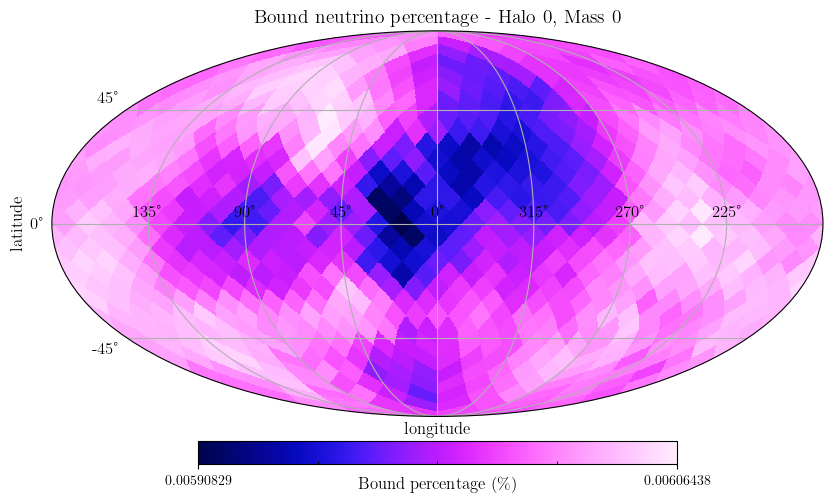

0.6571656312923594


<Figure size 1000x600 with 0 Axes>

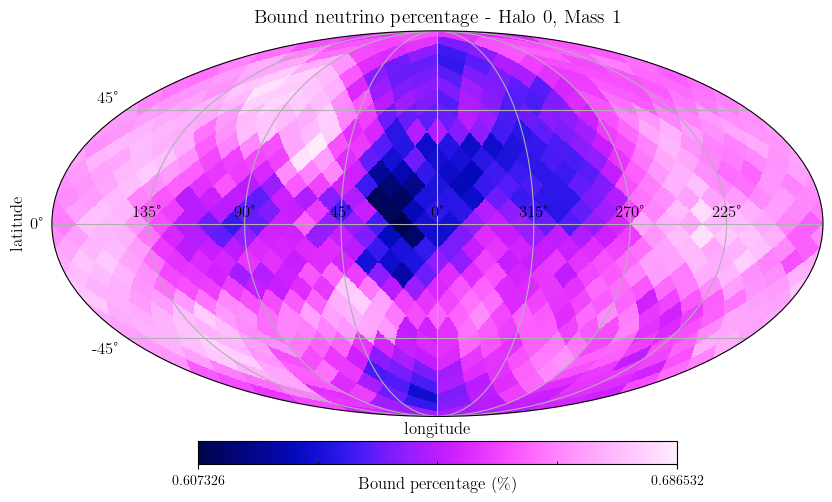

4.269705315229509


<Figure size 1000x600 with 0 Axes>

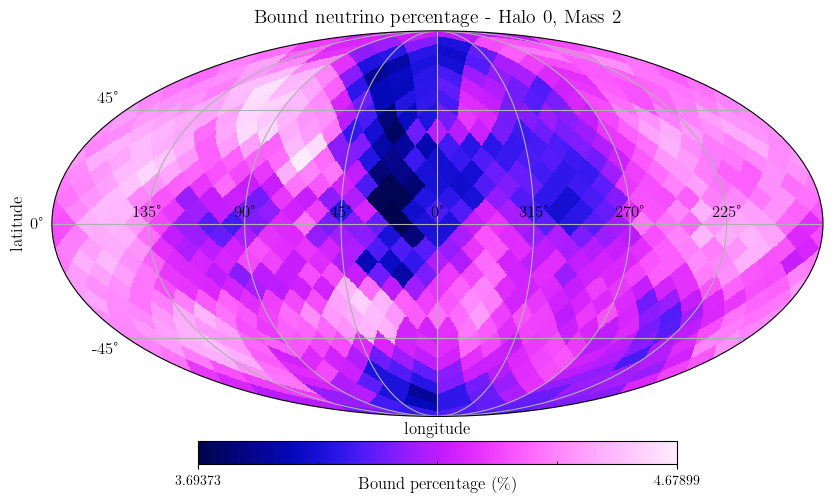

20.907792839562916


<Figure size 1000x600 with 0 Axes>

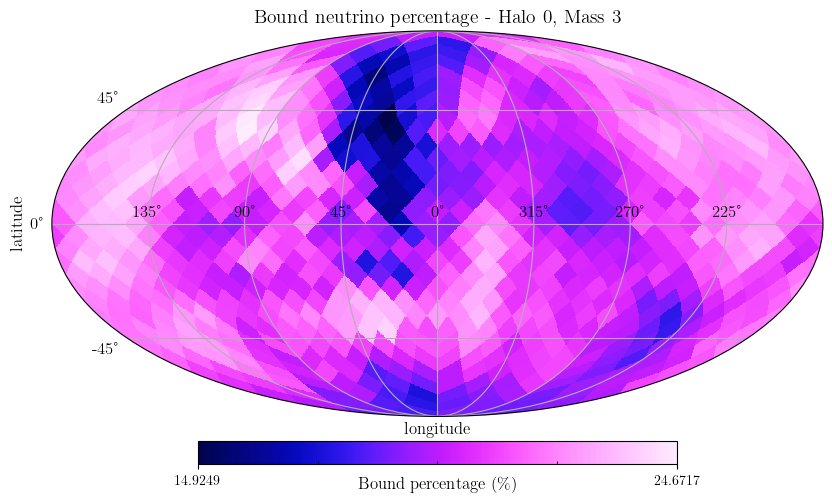

41.87165095076416


<Figure size 1000x600 with 0 Axes>

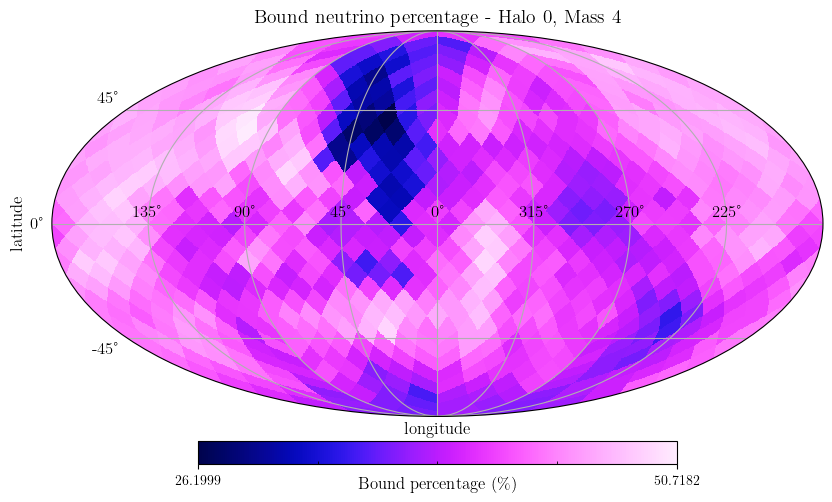

In [20]:
def plot_bound_percentage(percentages, halo_idx, mass_idx, title=None):

    # Extract the percentages for specific halo and mass (already in percentage units)
    # bound_map = percentages[halo_idx, mass_idx]

    bound_map = jnp.mean(percentages, axis=0)[mass_idx] 

    # Create figure
    plt.figure(figsize=(10, 6))

    # Plot using hp.newvisufunc.projview
    hp.newvisufunc.projview(
        bound_map,
        cmap=cc.cm.CET_L7,
        unit='%',
        title=title or f'Bound neutrino percentage - Halo {halo_idx}, Mass {mass_idx}',
        coord=['G'],
        graticule=True,
        graticule_labels=True,
        xlabel="longitude", 
        ylabel="latitude",
        cb_orientation="horizontal",
        projection_type="mollweide",
        flip='astro',
        latitude_grid_spacing=45,
        longitude_grid_spacing=45,
        phi_convention='counterclockwise',
    )

    print(jnp.mean(bound_map))

    # Adjust colorbar label
    plt.gcf().get_axes()[-1].set_xlabel(r'Bound percentage ($\%$)')

    return plt.gcf()


for i in range(len(nu_m_picks)):
    fig = plot_bound_percentage(percentages_method_1, halo_idx=0, mass_idx=i)
    plt.show()

## Computing $n_\nu$ for days via PSD interpolation

In [31]:
@jax.jit
def compute_PSDs_day(y_z4_days, y_z0_DM_sim, FD_vals_z0):
    # Vectorize the interpolation across all dimensions
    PSDs_day = Utils.vectorized_interpolate_1D(
        y_z4_days, y_z0_DM_sim, FD_vals_z0)
    return PSDs_day


def compute_nu_dens_days(
        days_steps,
        Fermi_Dirac:bool, bound:bool, int_over_pixels:bool):

    # List to store quantities for each day
    days_nrs_l = []
    n_nu_days_l = []
    percs_days_l = []

    # Get Earth velocities w.r.t. the GC, since DM sims are in that frame
    # note: This includes ("inherited") solar system motion
    # _, _, earth_vels = SimPlot.SunEarthGC_frame_coords(2024)
    _, _, earth_vels = SunEarthGC_frame_coords_local(2024)
    earth_vels *= (Params.km/Params.s)/(Params.kpc/Params.s)

    
    ### ================== ###
    ### DM halo simulation ###
    ### ================== ###

    # Neutrino velocities
    halo_num = 3
    DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

    # Sorted momenta arrays    
    _, p_z0_DM_sim, p_z4_DM_sim, y_z0_DM_sim, _ = Utils.sim_vels_to_sorted_z0z4(
        DM_sim_vels, nu_m_picks, 
        merge_last_axes=False, args=Params())

    # PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
    FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
    # (halos, masses, Npix, p_num)

    # Escape momentum
    x_i_Earth = jnp.array([8.127, 0., 0.])*Params.kpc
    p_esc_arr, _ = get_p_esc(sim_folder, x_i_Earth, nu_m_picks, Params())


    ### ==================== ###
    ### Solar modulation sim ###
    ### ==================== ###

    for day in range(0, 365, days_steps):

        # Load velocities for current day
        file_path = f"{sim_folder}/vectors_day{day+1}.npy"

        if os.path.exists(file_path):

            print(f"Day {day+1}/365")
            days_nrs_l.append(day+1)
            
            # Velocities from simulation frame to Earth frame
            # (insert halo dimension at beginning to synchronize)
            day_vels = SimUtil.CNB_to_Earth_frame_trafo(
                jnp.load(file_path)[..., 3:][None, ...],  # sim vels
                earth_vels[day])
            
            #? not convinced yet, that all quantities are properly synced, i.e. do all quantities corresponds to the same day? sim backwards but called day 1, day 2, etc? But earth's motion forward in time then called day 1, day 2, etc. also? lots to double check

            # Sorted momenta arrays
            _, p_z0_days, p_z4_days, _, _ = Utils.sim_vels_to_sorted_z0z4(
                day_vels, nu_m_picks, 
                merge_last_axes=False, args=Params())
            
            sort_ind, _, _, _, y_z4_days = Utils.sim_vels_to_sorted_z0z4(
                day_vels, nu_m_picks, 
                merge_last_axes=False, args=Params())

            if Fermi_Dirac:
                PSDs_days = Physics.Fermi_Dirac(p_z4_days, Params())

            else:
                # This function needs arrays to have unmerged last axes
                # (so merge_last_axes=False used above for arrays used here)
                PSDs_days = compute_PSDs_day(
                    jnp.repeat(y_z4_days, len(y_z0_DM_sim), axis=0), y_z0_DM_sim, FD_vals_z0)
                
                # Now merge last 2 axes and sort
                # PSDs_days = PSDs_days.reshape(*PSDs_days.shape[:-2], -1)
                PSDs_days = jnp.take_along_axis(PSDs_days, sort_ind, axis=-1)


            ### ================================= ###
            ### Compute number densities for days ###
            ### ================================= ###

            # note: edge effect of interpolation can cause values above 0.5
            PSDs_days = jnp.clip(PSDs_days, a_min=None, a_max=0.5)

            if bound:
                # Integrate only up to escape momentum
                esc_cond = p_z0_days < p_esc_arr[:halo_num, :, None, None]
                # esc_cond = p_z0_days >= p_esc_arr[:halo_num, :, None, None]

                # Set PSD values to zero, where condition is False
                if int_over_pixels:
                    PSDs_cond = jnp.where(esc_cond, PSDs_days, 0.)
                else:
                    ...

                # Integral over domain from condition (either bound or unbound)
                n_raw = trap(
                    p_z0_days**3*PSDs_cond, jnp.log(p_z0_days), axis=-1)
                
                # Normalisation integral over total momentum range
                n_norm = trap(
                    p_z0_days**3*PSDs_days, jnp.log(p_z0_days), axis=-1)
            else:
                n_raw = trap(
                    p_z0_days**3*PSDs_days, jnp.log(p_z0_days), axis=-1)


            if int_over_pixels:
                # note: integration over individual pixels
                pix_sr = 4*Params.Pi/simdata.Npix
                n_cm3 = pix_sr*Params.g_nu/((2*jnp.pi)**3)*n_raw/Params.cm**-3
                n_cm3_pix = jnp.array(n_cm3)
                n_tot = jnp.sum(n_cm3_pix, axis=-1)
            else:
                # note: integration over all neutrinos
                pix_sr = 4*Params.Pi
                n_cm3 = pix_sr*Params.g_nu/((2*jnp.pi)**3)*n_raw/Params.cm**-3
                n_tot = jnp.array(n_cm3)

            n_nu_days_l.append(n_tot)

            if bound:
                perc = (n_raw/n_norm)*100
                percs_days_l.append(perc)

        else:
            pass

    days_nrs = jnp.array(days_nrs_l)
    n_nu_days = jnp.array(n_nu_days_l)
    percs_days = jnp.array(percs_days_l)

    return days_nrs, n_nu_days, percs_days


FD_bool = True
bound_bool = False
int_bool = False

days_nrs, n_nu_days, percs_days, = compute_nu_dens_days(
    days_steps=24,  # e.g. 24, 48 96 for faster testing, for all days set to 1
    # days_steps=400,
    Fermi_Dirac=False, bound=True, int_over_pixels=True)

# """
# Helper function to add substring conditionally with underscore handling
def add_if_true(condition, string):
    return f"_{string}" if condition else ""

nu_base_name = "n_nu_days"
nu_filename = (f"{sim_folder}/{nu_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
           f"{add_if_true(bound_bool, 'bound')}"
        #    f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
jnp.save(nu_filename, n_nu_days)

nrs_base_name = "days_nrs"
nrs_filename = (f"{sim_folder}/{nrs_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
           f"{add_if_true(bound_bool, 'bound')}"
        #    f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
jnp.save(nrs_filename, days_nrs)
# """


print(percs_days.shape)
mi = 3
print(percs_days[0,0,mi,:].min())
print(jnp.median(percs_days[0,0,mi,:]))
print(percs_days[0,0,mi,:].max())

Day 1/365
Day 25/365
Day 49/365
Day 73/365
Day 97/365
Day 121/365
Day 145/365
Day 169/365
Day 193/365
Day 217/365
Day 241/365
Day 265/365
Day 289/365
Day 313/365
Day 337/365
Day 361/365
(16, 3, 5, 768)
10.143005222033596
21.898322948953897
28.410980578314128


## Computing and plotting annual modulations

n_nu_days shape: (16, 3, 5)


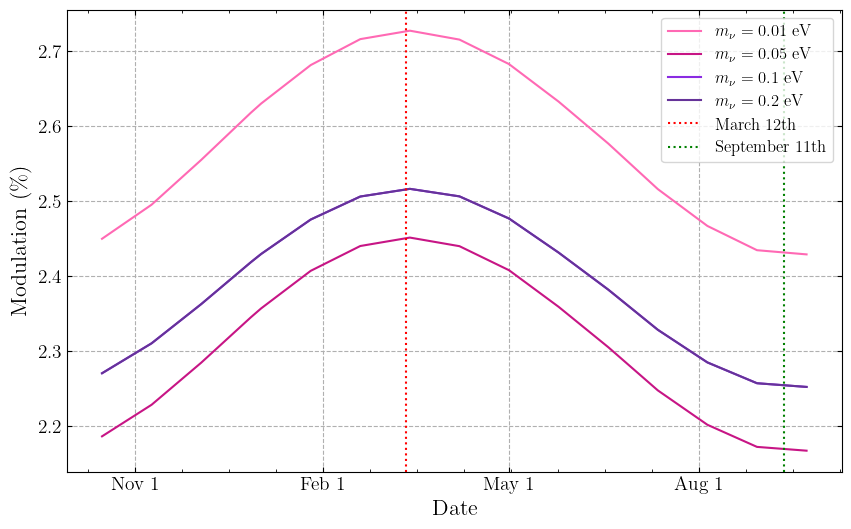

In [37]:
def modulation_band(
        nu_dens_days, simulated_days, nu_m_picks, 
        start_date_str='09-11', mode='modulation'):
    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')
    
    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    # Shift days to start from the specified date
    shifted_days = (simulated_days - start_day_of_year) % 365 + 1
    sorted_indices = jnp.argsort(shifted_days)
    shifted_days = shifted_days[sorted_indices]

    # Adjust vertical lines for March 12th and September 11th
    march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1

    violet_colors = [
        # "lightpink",
        "hotpink", 
        "mediumvioletred", 
        "blueviolet",
        "rebeccapurple",
    ]

    for m_idx, (m_val, color) in enumerate(zip(nu_m_picks, violet_colors)):
        
        if FD_bool:
            nu_dens_m = nu_dens_days[:, m_idx]  # (days,)
        else:
            nu_dens_m = nu_dens_days[:, :, m_idx]  # (days, halos)

        #? Since we started from Dec 31st to Jan 1st, we should flip array?
        nu_dens_m = jnp.flip(nu_dens_m, axis=0)

        # Compute fractional modulation for each halo
        nu_min = jnp.min(nu_dens_m, axis=0)
        mod = (nu_dens_m - nu_min) / (nu_dens_m + nu_min) * 100

        if mode == 'densities':
            mod = nu_dens_m

        # Sort modulation values for each day
        # mod_sorted = jnp.sort(mod, axis=1)

        # Compute median and 1-sigma band
        median = jnp.median(mod, axis=-1)
        lower = jnp.percentile(mod, 16, axis=-1)
        upper = jnp.percentile(mod, 84, axis=-1)

        # Apply sorting to match shifted_days
        median = median[sorted_indices]
        lower = lower[sorted_indices]
        upper = upper[sorted_indices]

        # Plot median and 1-sigma band
        ax.plot(shifted_days, median, '-', color=color, label=fr"$m_\nu = {m_val}$ eV")
        # ax.fill_between(shifted_days, lower, upper, color=color, alpha=0.3)

    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']

    plt.xticks(tick_days, tick_labels)

    # Set axis limits and labels
    # plt.ylim(0, 5)
    plt.ylabel(r'Modulation ($\%$)')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, which="major", linestyle="dashed")

    plt.axvline(x=march_12, color='r', linestyle=':', label='March 12th')
    plt.axvline(x=sept_11, color='g', linestyle=':', label='September 11th')

    plt.legend(prop={"size":12})

    modulation_base_name = "modulation"
    modulation_filename = (f"{fig_folder}/{modulation_base_name}"
            f"{add_if_true(FD_bool, 'FD')}"
            f"{add_if_true(bound_bool, 'unbound')}"
            f"{add_if_true(int_bool, 'int_pixels')}"
            ".pdf")

    plt.savefig(modulation_filename, bbox_inches="tight")

    plt.show()
    plt.close()


FD_bool = True
bound_bool = False
int_bool = False

# Helper function to add substring conditionally with underscore handling
def add_if_true(condition, string):
    return f"_{string}" if condition else ""

nu_base_name = "n_nu_days"
nu_filename = (f"{sim_folder}/{nu_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
           f"{add_if_true(bound_bool, 'bound')}"
        #    f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
n_nu_days = jnp.load(nu_filename)

nrs_base_name = "days_nrs"
nrs_filename = (f"{sim_folder}/{nrs_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
           f"{add_if_true(bound_bool, 'bound')}"
        #    f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
days_nrs = jnp.load(nrs_filename)

print(f"n_nu_days shape: {n_nu_days.shape}")

# Call the modulation function with the full n_nu_days array
modulation_band(
    # nu_dens_days=n_nu_days/Params.N0_cm3, 
    nu_dens_days=n_nu_days, 
    simulated_days=days_nrs, 
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities'
)

In [23]:
gc_factors = [1, 1.05, 1.175, 1.5]
print([f"{perc/100*gc_factor*Params.N0_cm3:.2f}" for (perc, gc_factor) in zip(gc_factors, percentages[:-1])])

['0.00', '0.42', '2.64', '10.52']
